# Objectif du notebook 

Date de création :30/03/2026

L'objectif du notebook est d'approfondir l'utilisation des distributions du module de $\Pi$ comme grandeur caractéristique de la position de la source. 


In [1]:
# %matplotlib notebook

import os
import sys
import numpy as np
import xarray as xr
import pandas as pd
import scipy.signal as sp 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from scipy.special import kl_div
from scipy.interpolate import interp1d
from scipy.spatial.distance import cdist, jensenshannon
from scipy.stats import (
    wasserstein_distance,
    wasserstein_distance_nd,
    entropy,
    gaussian_kde,
)
from datetime import timedelta, datetime
from scipy.stats import linregress
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
project_root = os.path.abspath(
    os.path.join(os.path.dirname(os.getcwd()), "..", "..", "..", "..", "..")
)
root_groix_data = os.path.join(project_root, "data", "fiberscope_groix_oct_2025")
root_groix_wav = os.path.join(root_groix_data, "wav")
root_groix_metadata = os.path.join(root_groix_data, "metadata")

root_folder = os.path.join(project_root, "real_data_analysis", "fiberscope_groix")
data_folder = os.path.join(root_folder, "data")
img_folder = os.path.join(root_folder, "img")

sensibility_img_folder = os.path.join(img_folder, "rtf_mfp", "sensibility")

In [3]:
sys.path.append(project_root)
from publication.publication_figure import (
    PubFigure,
    LargeFigure,
    color,
    set_subfigures_abc_labels,
)
from propa.rtf.rtf_utils import D_hermitian_angle_fast, D_euclidian


from real_data_analysis.fiberscope_groix.src.fiberscope_groix_manager import (
    # ActiveFiberscopeManager,
    # PassiveFiberscopeManager,
    BandFilter,
)

from real_data_analysis.fiberscope_groix.src.localisation.rtf.rtf_mfp import (
    RTF_MFP_Processor,
)
from misc import progression_bar

from real_data_analysis.fiberscope_groix.src.localisation.rtf.sensibility.sensibility_study_utils import *

# Étape 1 : chargement de la données 

## Sélection d'une sous partie de la séquence

Afin de simplifier l'étude, la séquence est réduite aux émissions comprises entre l'OBS 1 et l'OBS 3 (émissions n°50 à n°170).

In [4]:
# Load GPS dataset for station coordinates
ds_gps = xr.open_dataset(os.path.join(data_folder, "gps.nc"))

# Load arrivals dataset
fpath = os.path.join(
    data_folder,
    f"processed_arrivals.nc",
)
ds_arr = xr.open_dataset(fpath)
df_arr = ds_arr.to_dataframe()

In [5]:
seq_id = 144
df_seq = df_arr.loc[df_arr["sequence_id"] == seq_id]

# Select only pulses emitted between OBS1 and OBS3
pulse_slice = (100, 220)
# pulse_slice = (60, 140)

df_seq = df_seq.loc[df_seq["pulse_id"].between(*pulse_slice)]

root_fig = os.path.join(sensibility_img_folder, f"{seq_id}")
if not os.path.exists(root_fig):
    os.makedirs(root_fig)

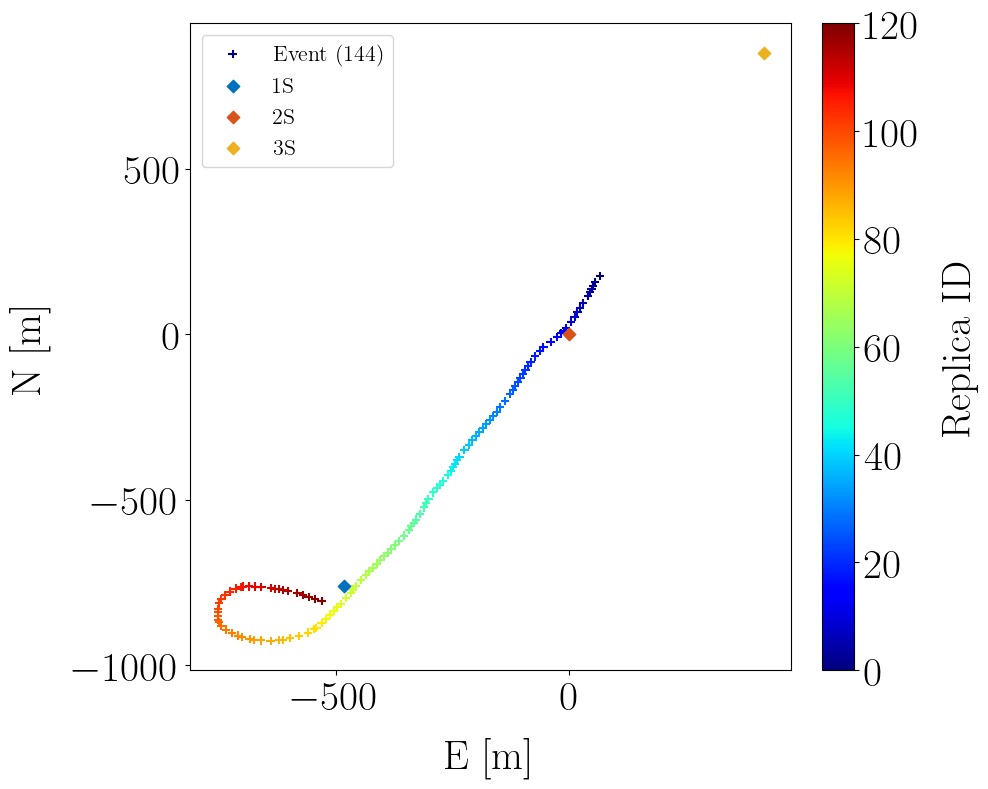

In [6]:
plot_seq_replica_positions(df_seq, ds_gps, root_fig)

Median source speed along traj : vs = 1.81 m.s-1
Std source speed along traj : vs = 0.34 m.s-1


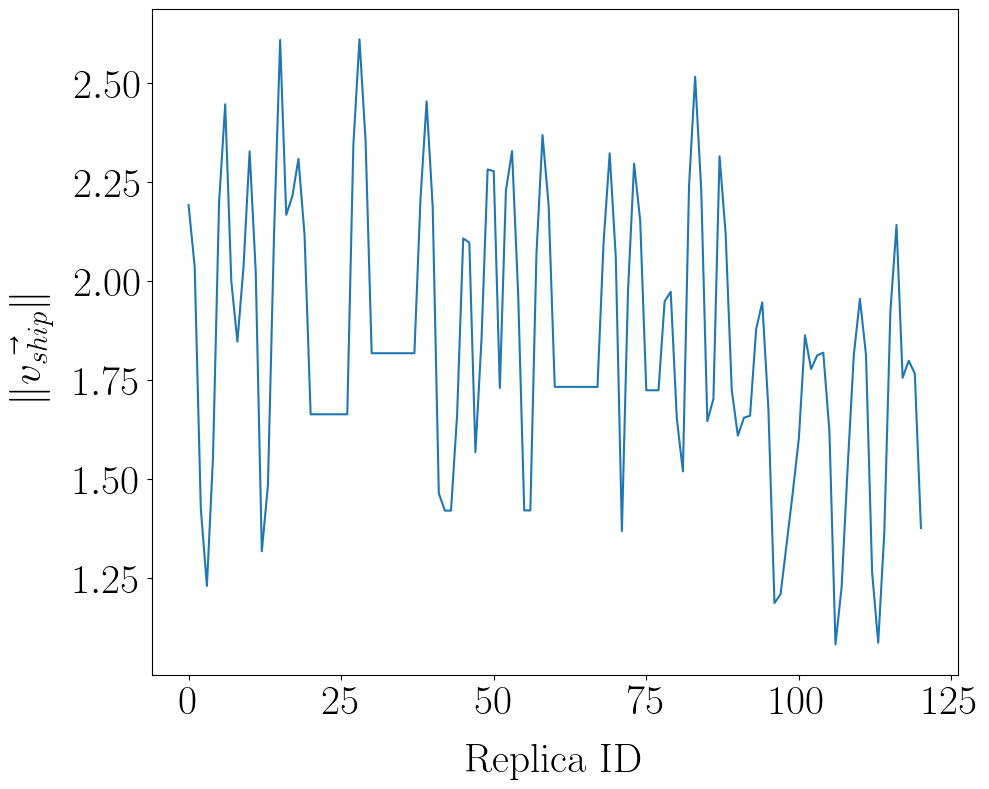

In [7]:
plot_speed_along_seq(df_seq, root_fig)

## Calcul / chargement de la grandeur signante


In [8]:
root_data = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data"
root_img = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\img\rtf_mfp"
ref_rcv_id = 1
rtf_estimator = "cs-evd"

tau_ir_hat = 0.2  # estimated impulse response duration from sequence 144
tau_ir_hat *= 2  # To ensure we include the entire response


fsm_active_kwargs = {
    "bandfilter": None,
    "tau_ir": tau_ir_hat,
    "process_pulse_one_by_one": True,
    "estimate_ir_duration": False,
}
fsm_passive_kwargs = {
    "analysis_segment_duration": 5,
    "analysis_segment_alpha_overlap": 0,
}

fsm_props = {
    "fs": 2000,
    # "tau_rtf_analysis": 3,
    # "alpha_overlap": 0.5,
    # From the sensibility study below 
    "tau_rtf_analysis": 3.0,
    "alpha_overlap": 0.9,
}

rtf_mfp_processor = RTF_MFP_Processor(
    root_data=root_data,
    root_img=root_img,
    reference_receiver_id=ref_rcv_id,
    rtf_estimator=rtf_estimator,
    fsm_props=fsm_props,
    fsm_active_kwargs=fsm_active_kwargs,
    fsm_passive_kwargs=fsm_passive_kwargs,
    mode="overwrite",
    plot_replicas_features=False,
    verbose=True,
)

In [9]:
###########################
# Dummy
###########################
id_library = 10

active_replicas_args = {
    "replica_sequence_ids": [144],
    "replica_pulse_slice": [pulse_slice],
    "load_precomputed_feature": False,
}
passive_replicas_args = {
    "start_datetimes": [],
    "end_datetimes": [],
    "load_precomputed_feature": False,
}

# id_library = 11
# active_replicas_args = {
#     "replica_sequence_ids": [],
#     "replica_pulse_slice": [],
#     "load_precomputed_feature": False,
# }
# passive_replicas_args = {
#     "start_datetimes": [
#         datetime(year=2025, month=10, day=15, hour=10, minute=14, second=00),  # OK
#     ],
#     "end_datetimes": [
#         datetime(year=2025, month=10, day=15, hour=10, minute=18, second=00),  # OK
#     ],
#     "load_precomputed_feature": False,
# }

rtf_mfp_processor.compute_library(
    active_feature_args=active_replicas_args,
    passive_feature_args=passive_replicas_args,
    id=id_library,
)


Deriving features for active source...

RTF processing of sequences [144] (nb of sequences = 1)
Progress: ████████████████████████████████████████████████████████████████████████████████████████████████████ 100%
RTF feature estimation for sequence 144
Progress: ████████████████████████████████████████████████████████████████████████████████████████████████████ 100%
Deriving replicas for passive source...
A library dataset with ID 10 already exists in C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data\library. This library dataset will be overwritten.
Dataset (library) saved at C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data\library\library_10.nc.


In [10]:
print(rtf_mfp_processor.fsm_active.cm.nperseg, rtf_mfp_processor.fsm_active.cm.noverlap)
print(2**13)

8192 7372
8192


In [11]:
fpath = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data\library\library_10.nc"
ds = xr.open_dataset(fpath)
ds

<xarray.Dataset> Size: 30MB
Dimensions:           (h_index: 3, f_rtf: 4097, replica_id: 121, f_deconv: 5401)
Coordinates:
  * h_index           (h_index) int64 24B 1 2 3
  * f_rtf             (f_rtf) float32 16kB 0.0 0.2441 0.4883 ... 999.8 1e+03
  * replica_id        (replica_id) int64 968B 0 1 2 3 4 ... 116 117 118 119 120
  * f_deconv          (f_deconv) float32 22kB 0.0 0.1852 0.3703 ... 999.7 999.9
Data variables:
    rtf_amp           (h_index, f_rtf, replica_id) float32 6MB ...
    rtf_phase         (h_index, f_rtf, replica_id) float32 6MB ...
    rtf_amp_deconv    (h_index, f_deconv, replica_id) float32 8MB ...
    rtf_phase_deconv  (h_index, f_deconv, replica_id) float32 8MB ...
    feature_psd       (f_rtf, replica_id) float32 2MB ...
    e_replica         (replica_id) float32 484B ...
    n_replica         (replica_id) float32 484B ...
    u_replica         (replica_id) float32 484B ...
    replica_type      (replica_id) int64 968B ...
Attributes: (12/16)
    reference_receiver_id:  1
    rtf_estimator:          cs-evd
    replica_type_1:         active
    replica_type_2:         passive
    description:            Library dataset containing RTF-MFP features for a...
    type:                   library
    ...                     ...
    obs2_n_apriori:         0.0
    obs2_u_apriori:         0.0
    obs3_e_apriori:         418.25417297268984
    obs3_n_apriori:         850.5744968832777
    obs3_u_apriori:         -7.991059774156952
    id:                     10

In [12]:
# Select frequency range
fmin = 200
fmax = 900
# Slice frequency
ds = ds.sel(f_rtf=slice(fmin, fmax), f_deconv=slice(fmin, fmax))

freq = ds.f_rtf.values
freq_deconv = ds.f_deconv.values

# Build complex RTFs
rtf_cs_evd = ds.rtf_amp * np.exp(1j * ds.rtf_phase)
rtf_deconvolution = ds.rtf_amp_deconv * np.exp(1j * ds.rtf_phase_deconv)

In [13]:
fig_folder = os.path.join(sensibility_img_folder, "144", f"library_{ds.id}")
os.makedirs(fig_folder, exist_ok=True)

In [14]:
fpath = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_groix\data\sequences\active\sequence_144_rtf.nc"
ds_sig = xr.open_dataset(fpath)
ds_sig

<xarray.Dataset> Size: 126MB
Dimensions:                     (h_index: 3, time: 1952284, pulse_id: 121,
                                 t_ir: 10801, f_ir: 5401, f_rtf: 4097,
                                 f_csdm: 4097, h_index_bis: 3)
Coordinates:
  * h_index                     (h_index) int64 24B 1 2 3
  * time                        (time) float32 8MB 0.0 0.0005 ... 976.1 976.1
  * pulse_id                    (pulse_id) int32 484B 100 101 102 ... 219 220
  * t_ir                        (t_ir) float32 43kB 0.0 0.0005 ... 5.399 5.4
  * f_ir                        (f_ir) float32 22kB 0.0 0.1852 ... 999.7 999.9
  * f_rtf                       (f_rtf) float32 16kB 0.0 0.2441 ... 999.8 1e+03
  * f_csdm                      (f_csdm) float32 16kB 0.0 0.2441 ... 999.8 1e+03
  * h_index_bis                 (h_index_bis) int64 24B 1 2 3
Data variables:
    signal                      (h_index, time) float32 23MB ...
    arr_time_in_sec_from_start  (h_index, pulse_id) float32 1kB ...
    ri_hat                      (h_index, t_ir, pulse_id) float32 16MB ...
    tf_hat_amp                  (h_index, f_ir, pulse_id) float32 8MB ...
    tf_hat_phase                (h_index, f_ir, pulse_id) float32 8MB ...
    rtf_amp_hat                 (h_index, f_rtf, pulse_id) float32 6MB ...
    rtf_phase_hat               (h_index, f_rtf, pulse_id) float32 6MB ...
    Rx                          (f_csdm, h_index, h_index_bis, pulse_id) float32 18MB ...
    Rv                          (f_csdm, h_index, h_index_bis, pulse_id) float32 18MB ...
    rtf_amp                     (h_index, f_ir, pulse_id) float32 8MB ...
    rtf_phase                   (h_index, f_ir, pulse_id) float32 8MB ...
Attributes: (12/17)
    fs:                        2000
    ts:                        0.0005
    t0:                        5.0
    t1:                        5.59
    datetime_format:           %Y-%m-%d_%H-%M-%S
    start_datetime:            2025-10-16_11-04-25
    ...                        ...
    inter_pulse_period:        8.0
    process_pulse_one_by_one:  1
    root_img:                  C:\Users\baptiste.menetrier\Desktop\devPy\phd\...
    root_data:                 C:\Users\baptiste.menetrier\Desktop\devPy\phd\...
    h_index_ref:               1
    pulse_window_length_s:     10.04

## Visualisation des signaux 

In [15]:
# Load wav data and plot the corresponding sequence
ds_wav = xr.open_dataset(os.path.join(data_folder, "channel_H_wav.nc"))


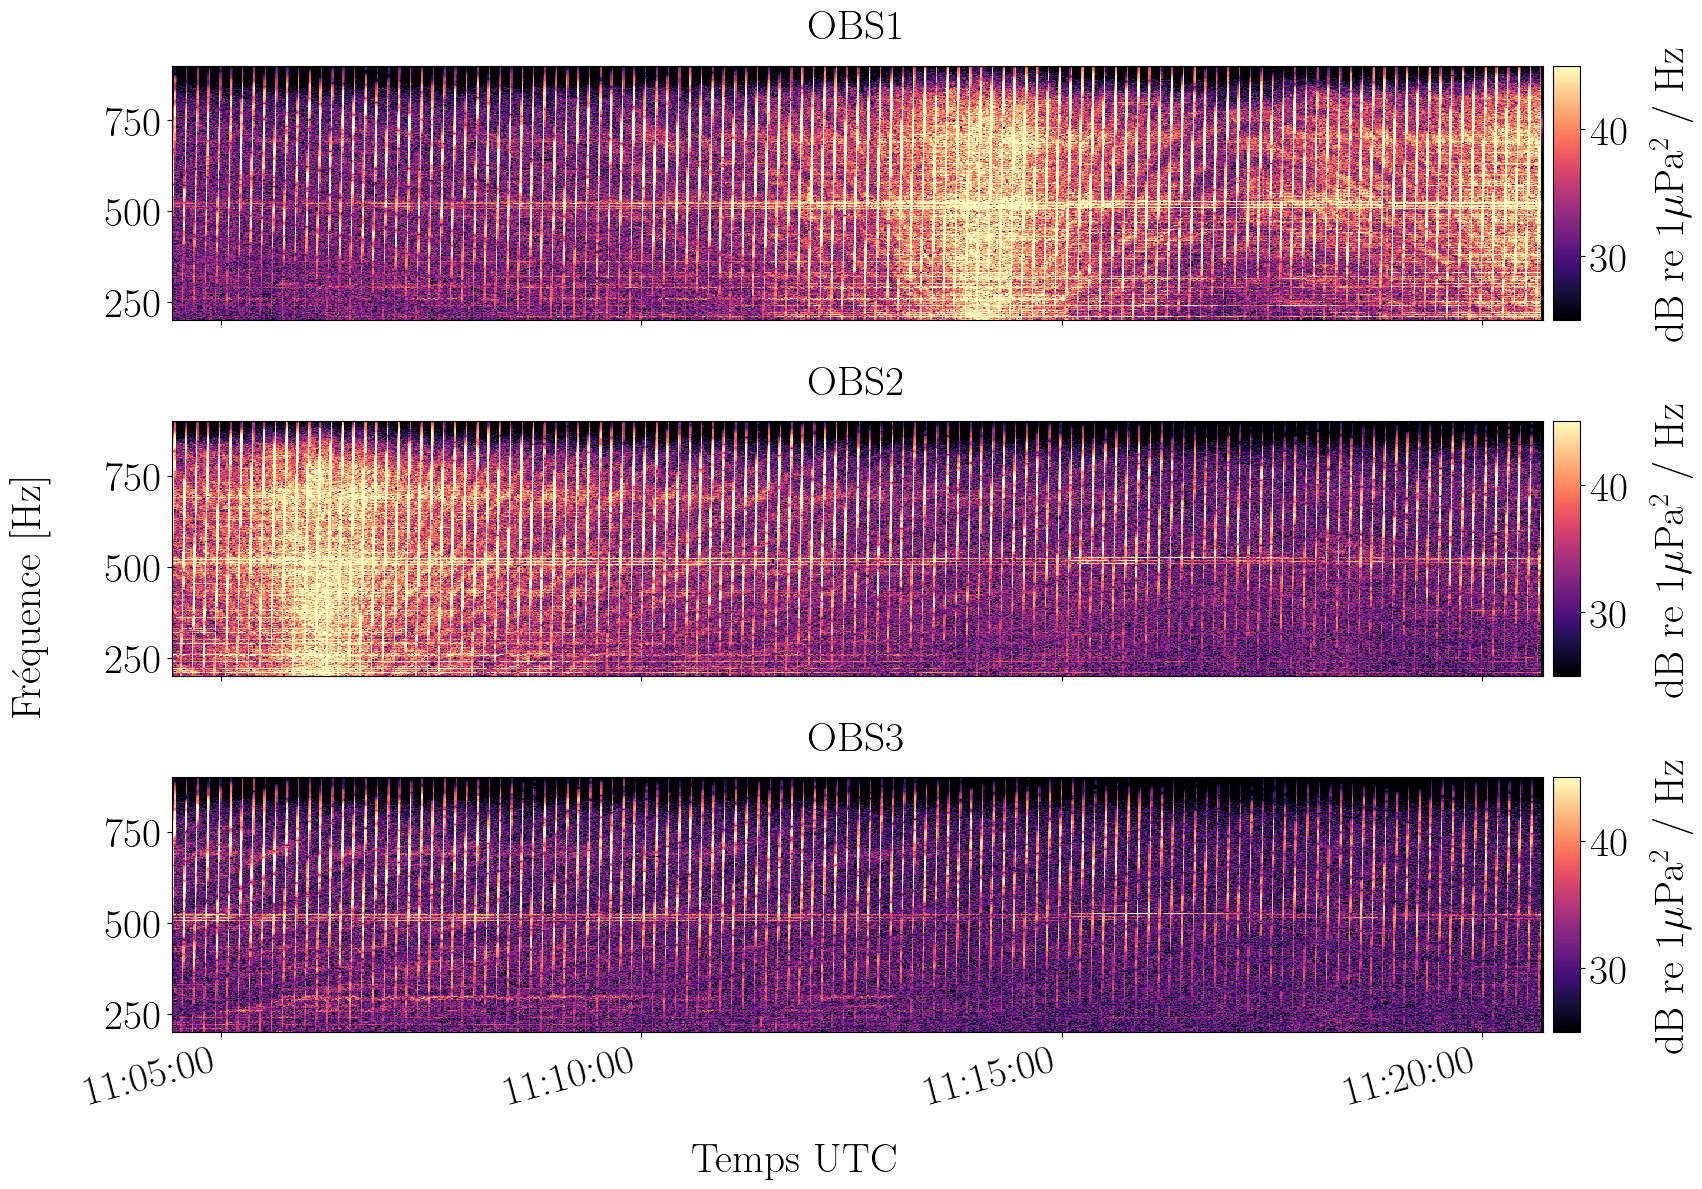

In [16]:
plot_sequence_spectrogram(ds_sig, ds_wav, fig_folder)

# Étape 2 : étude de la grandeur signante 

## Variations du module de $\Pi$ dans le plan (f, r)


On s'intéresse aux variations de $\lvert \Pi \rvert$ dans le plan (f, numéro de réplique). Ici, les hydrophones sont quasiment alignés, si l'on néglige les variations de vitesse du porteur et que l'on suppose donc que la source se déplace en ligne droite à vitesse constante, les variations dans le plan (f, numéro de réplique) sont équivalentes aux variations dans le plan (f, r). 

In [17]:
dist_rcv = get_dist_to_rcv(ds)
obs_cpa_idx = np.argmin(dist_rcv, axis=1).flatten()
reps = ds.replica_id.values

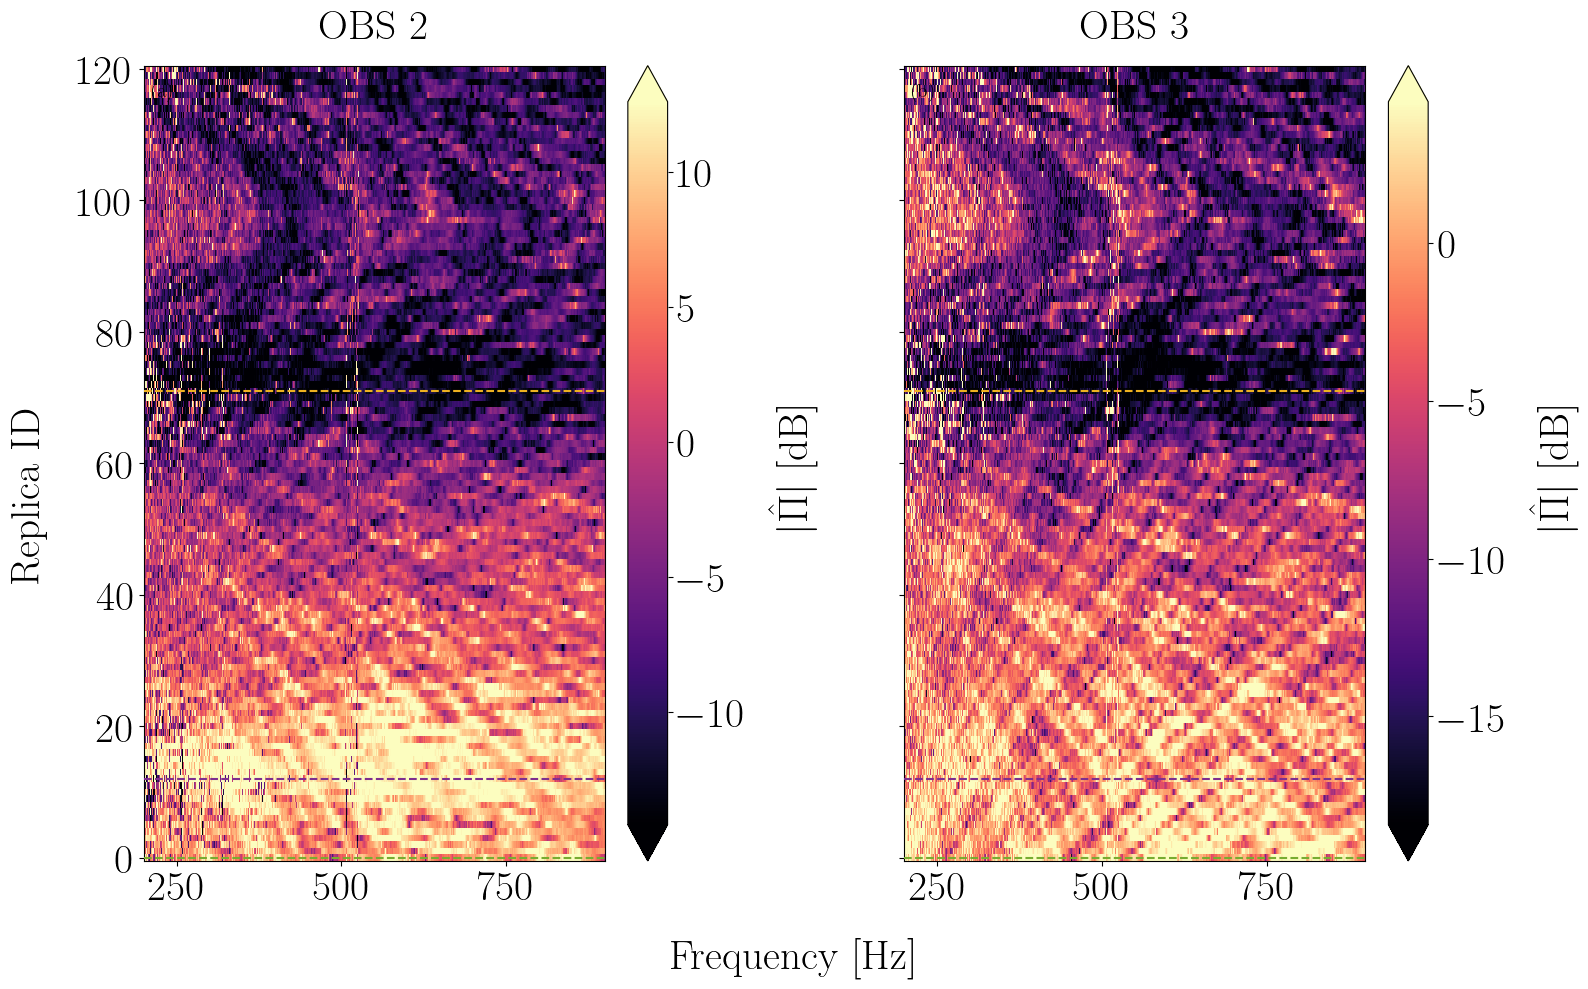

In [18]:
plot_rtf_mod_along_sequence(
    ds,
    dist_rcv,
    obs_cpa_idx,
    reps,
    fig_folder,
    replica_id_slice=slice(0, 200),
    fmin=200,
    fmax=900,
)

Cette représentation permet d'observer un certain nombre de structures qui évoluent dans le plan (f, r). Au vu des premières analyses menées en simulation, on peut supposer que ces figures résultent de la combinaison des franges d'interférences dans le plan (f, r) observées pour les différents couples de récepteurs. 

Cette visualisation est a priori encourageante pour la localisation et semble traduire une certaine continuité de la grandeur mesurée d'une position à une autre. Dit autrement, au vu de ces premiers résultats on peut espérer définir une métrique de similarité qui varie plus lentement au cours de la trajectoire de la source que la simple mesure de $\theta$ utilisée jusqu'ici. 


## Étude des distributions  

Dans ce notebook, on se propose d'explorer l'utilisation de distribution des modules afin de caractériser chacune des positions. L'idée est la suivante : 

* Pour une réplique donnée, le module de chaque composante $$\lvert \Pi_i(f) \rvert = \lvert  \frac{H_i}{H_{ref}} \rvert $ est vu comme un signal au sens où il représente une suite d'échantillon (en fonction de f). On peut ainsi calculer la distribution de valeur de cette quantité (i.e l'histogramme normalisé de sorte que l'intégrale vaut 1). 
* La distance entre deux répliques peut alors être évaluée à l'aide d'une métrique de distance entre distribution statistique. Il existe une multitude de métriques de ce type dans la littérature, il s'agit dans un premier temps de tester la viabilité de l'approche avec quelques distances a priori simples à mettre en œuvre.   

In [19]:
# def get_distribution_arr(rtf_module, n_bins=50, kde=False):
#     log_mod = 10 * np.log10(rtf_module)

#     # Derive histogram
#     # Define a common range of values for the histograms
#     log_mod_min = np.percentile(log_mod.values, 0.5)
#     log_mod_max = np.percentile(log_mod.values, 99.5)

#     reps = rtf_module.replica_id.values

#     log_mod_hist_arr = np.zeros((len(reps), n_bins))
#     for irep, rep in enumerate(reps):
#         log_mod_r = log_mod.sel(replica_id=rep)
#         log_mod_r_hist, bin_edges = np.histogram(
#             log_mod_r.values,
#             bins=n_bins,
#             range=(log_mod_min, log_mod_max),
#             density=True,
#         )

#         log_mod_hist_arr[irep, :] = log_mod_r_hist

#     bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

#     if kde:

#         log_mod_kde_arr = np.zeros((len(reps), n_bins))

#         for irep, rep in enumerate(reps):
#             log_mod_r = log_mod.sel(replica_id=rep)
#             # Ensure a common grid of values for the KDE
#             log_mod_r_sorted = np.sort(log_mod_r.values)
#             log_mod_r_idx_min = np.where(log_mod_r_sorted >= log_mod_min)[0][0]
#             log_mod_r_idx_max = np.where(log_mod_r_sorted <= log_mod_max)[0][-1]
#             log_mod_r = log_mod_r_sorted[log_mod_r_idx_min : log_mod_r_idx_max + 1]

#             # Apply Gaussian KDE
#             kde = gaussian_kde(log_mod_r)
#             log_mod_kde_arr[irep, :] = kde.pdf(bin_centers)
#     else:
#         log_mod_kde_arr = None

#     return log_mod_hist_arr, bin_centers, log_mod_kde_arr


In [20]:
# def get_distribution_distance(
#     log_mod_hist_arr, idx_rep_ref, distance=["shannon_entropy"]
# ):

#     # Reference distribution to compare with
#     mu_ref = log_mod_hist_arr[idx_rep_ref, :]

#     nreps = log_mod_hist_arr.shape[0]
#     distance_dict = {d_name: np.zeros(nreps) for d_name in distance}

#     for irep in range(nreps):
#         mu_r = log_mod_hist_arr[irep, :]

#         if "wasserstein" in distance: 
#             wd = wasserstein_distance(u_values=mu_ref, v_values=mu_r)
#             distance_dict["wasserstein"][irep] = wd

#         if "jensen_shannon" in distance:
#             js = jensenshannon(mu_ref, mu_r)
#             distance_dict["jensen_shannon"][irep] = js

#         if "shannon_entropy" in distance:
#             mu_ref_s = mu_ref.copy()
#             mu_ref_s[mu_ref_s == 0] = np.nan
#             mu_r_s = mu_r.copy()
#             mu_r_s[mu_r_s == 0] = np.nan
#             s = entropy(mu_ref_s, mu_r_s, nan_policy="omit")
#             distance_dict["shannon_entropy"][irep] = s

#         # kld = kl_div(mu_ref, mu_r)
            
#     return distance_dict

### A quoi ça ressemble ?

In [21]:
fmin = 200
fmax = 900
n_bins = 100
log_mod_hist, log_mod_kde, bin_centers = get_log_module_distributions(
    ds, fmin=fmin, fmax=fmax, n_bins=n_bins
)

#### Histogramme 

In [22]:
idx_rep_ref = 100
distance_dict_hist = get_distribution_distance_all_rcv(
    log_mod_distribution=log_mod_hist,
    idx_rep_ref=idx_rep_ref,
    distances=["wasserstein", "jensen_shannon", "shannon_entropy"],
)

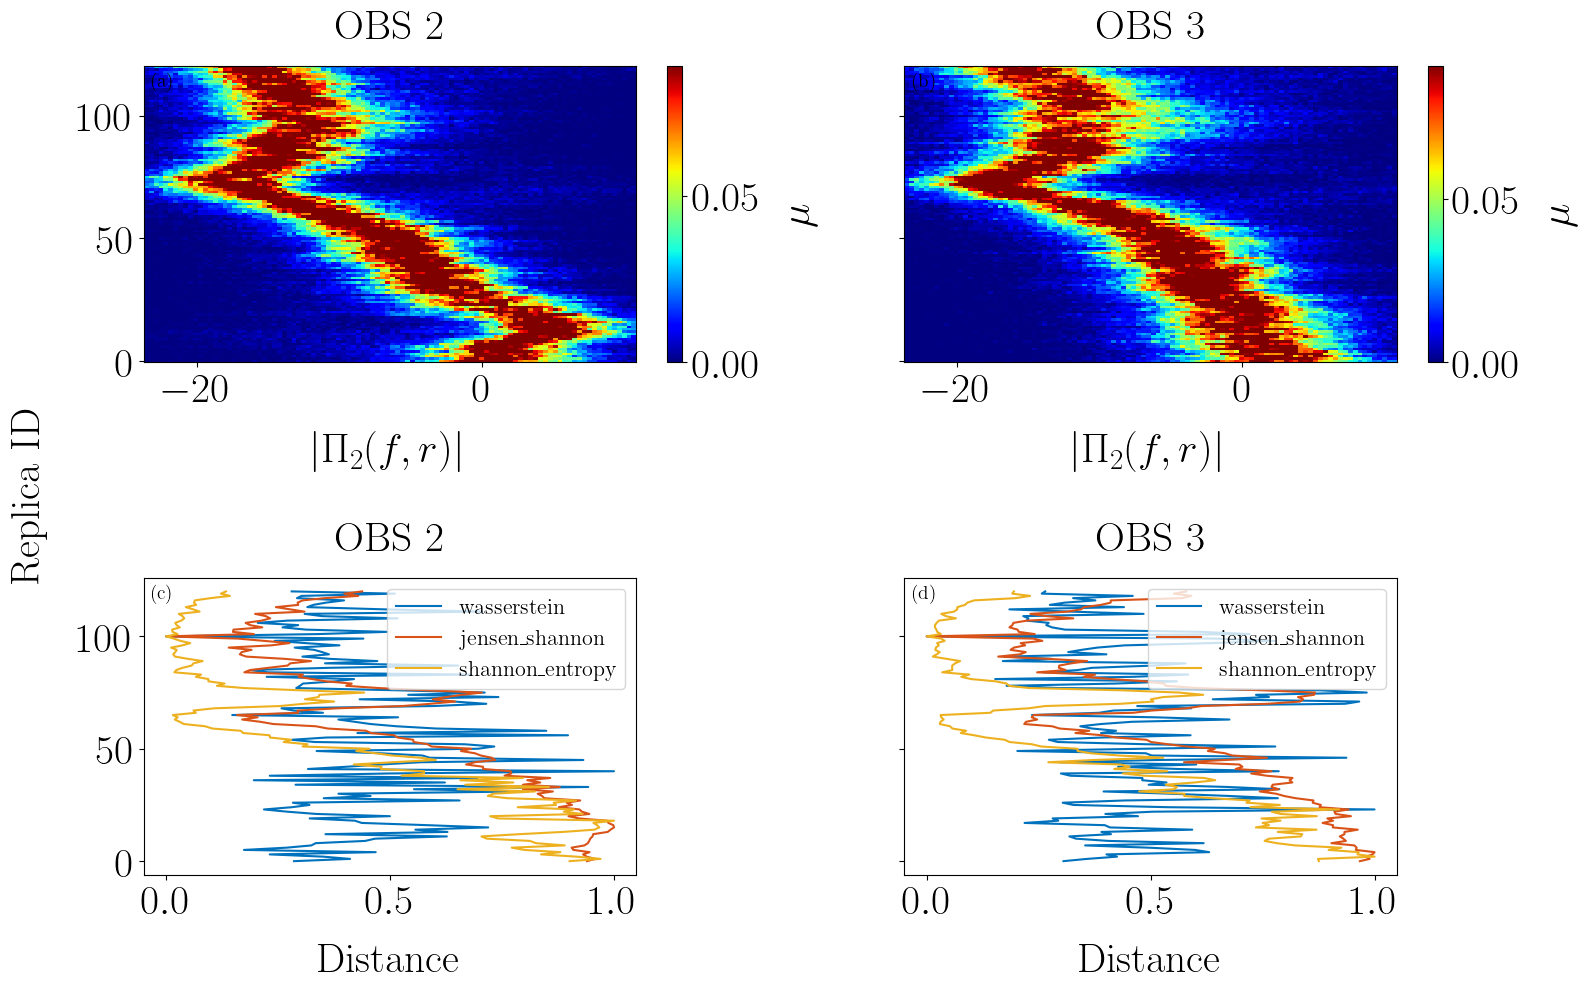

In [23]:
plot_log_mod_distribution_along_sequence(log_mod_hist, distance_dict_hist, bin_centers=bin_centers, replica_ids=ds.replica_id.values)

L'étude des distributions est encourageante. L'utilisation des distributions conduit à la perte d'une partie de l'information, en particulier l'ordonnancement des échantillons est perdue. Malgré cela, les distributions semblent évoluer de manière significative au cours de la trajectoire de la source. 

L'évolution de la moyenne de la distribution traduit a priori simplement l'évolution des pertes moyennes dans la bande considérée, la forme de la distribution doit encoder la spécificité du rapport de fonctions de transfert. 

La distance de Jensen-Shanon (JS) semble être davantage adaptée ici avec des variations significatives autour de la position de référence. Un point important est à noter, contrairement à la distance $\theta$, la distance JS ne présente pas de minimum au passage des CPAs des OBS.   

#### Gaussian KDE 

Au vu des distributions observées on peut estimer une densité de probabilité par application d'un noyau gaussien (qui performent a priori mieux sur les distributions unimodale). 

In [24]:
distance_dict_kde = get_distribution_distance_all_rcv(
    log_mod_distribution=log_mod_kde,
    idx_rep_ref=idx_rep_ref,
    distances=["wasserstein", "jensen_shannon", "shannon_entropy"],
)

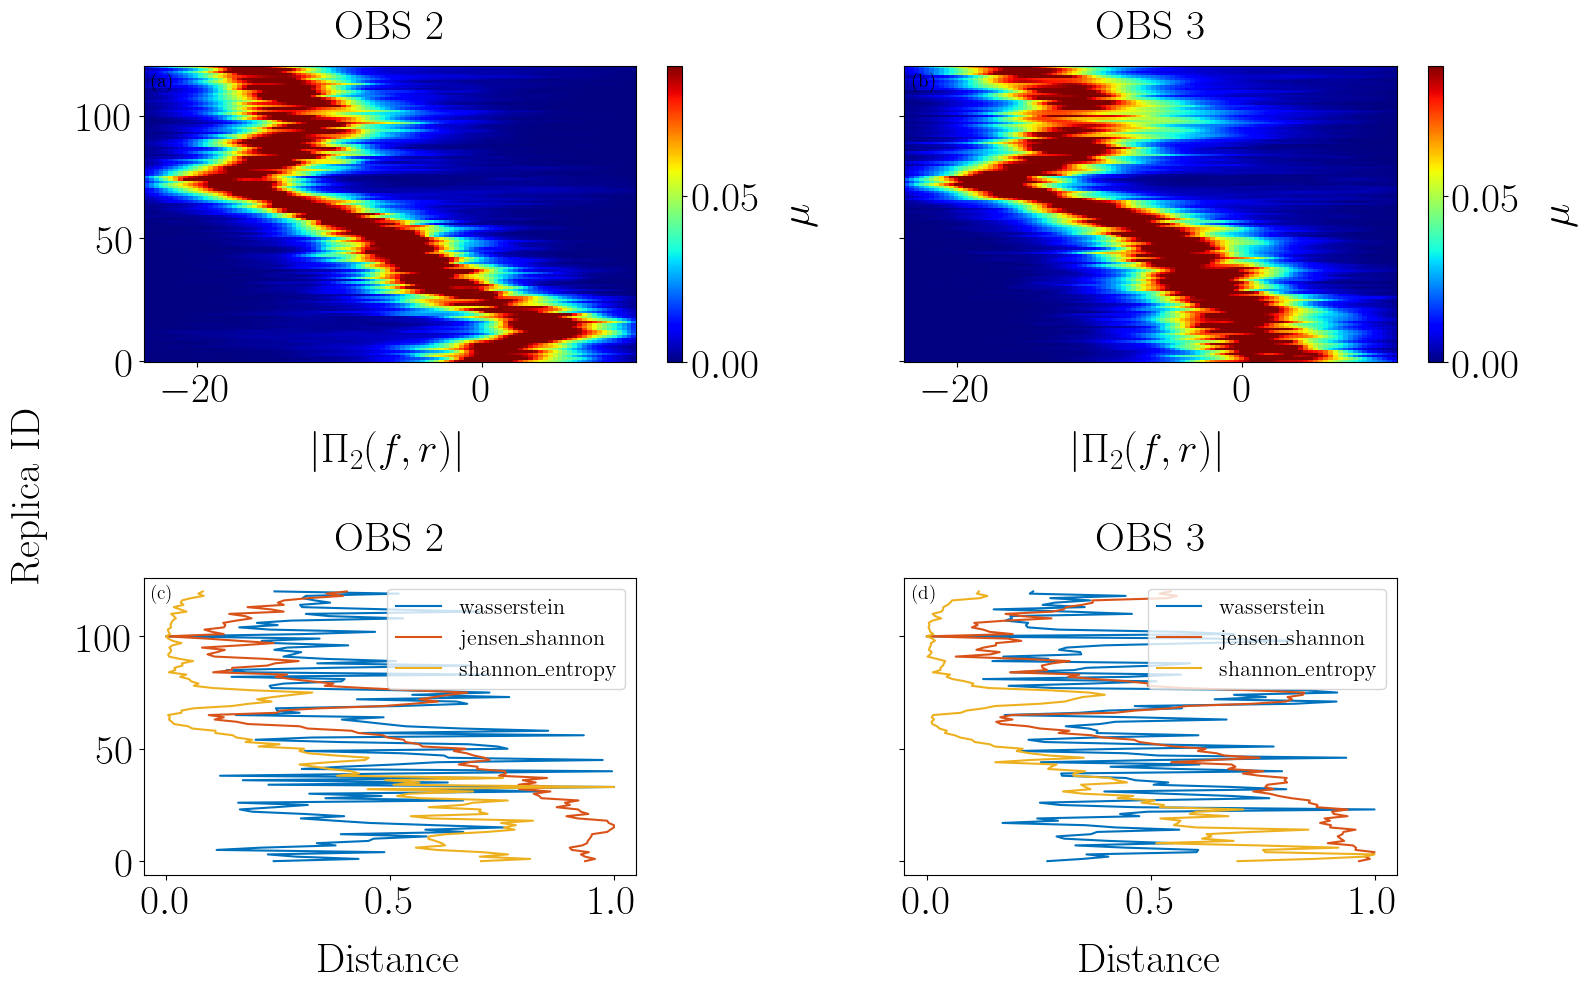

In [25]:
plot_log_mod_distribution_along_sequence(
    log_mod_kde,
    distance_dict_kde,
    bin_centers=bin_centers,
    replica_ids=ds.replica_id.values,
)

L'estimation de la densité de probabilité via un noyau gaussien conduit à un résultat très similaire. 

## Comparaison de plusieurs distances 

On se propose dans un premier temps de comparer les performances de différentes distances entre distributions : 

* Distance Jensen-Shanon
* Distance de Wasserstein 
* Divergence de Kullback-Liebler
* Entropie relative de Shannon 


### Distance sur les histogrammes 

In [26]:
idx_rep_ref = 100
distance_dict_hist = get_distribution_distance_all_rcv(
    log_mod_distribution=log_mod_hist,
    idx_rep_ref=idx_rep_ref,
    distances=["wasserstein", "jensen_shannon", "shannon_entropy"],
)

In [27]:
product_distance_dict_hist = get_combine_distance(
    distance_dict=distance_dict_hist, combine_method="product"
)
sum_distance_dict_hist = get_combine_distance(
    distance_dict=distance_dict_hist, combine_method="sum"
)

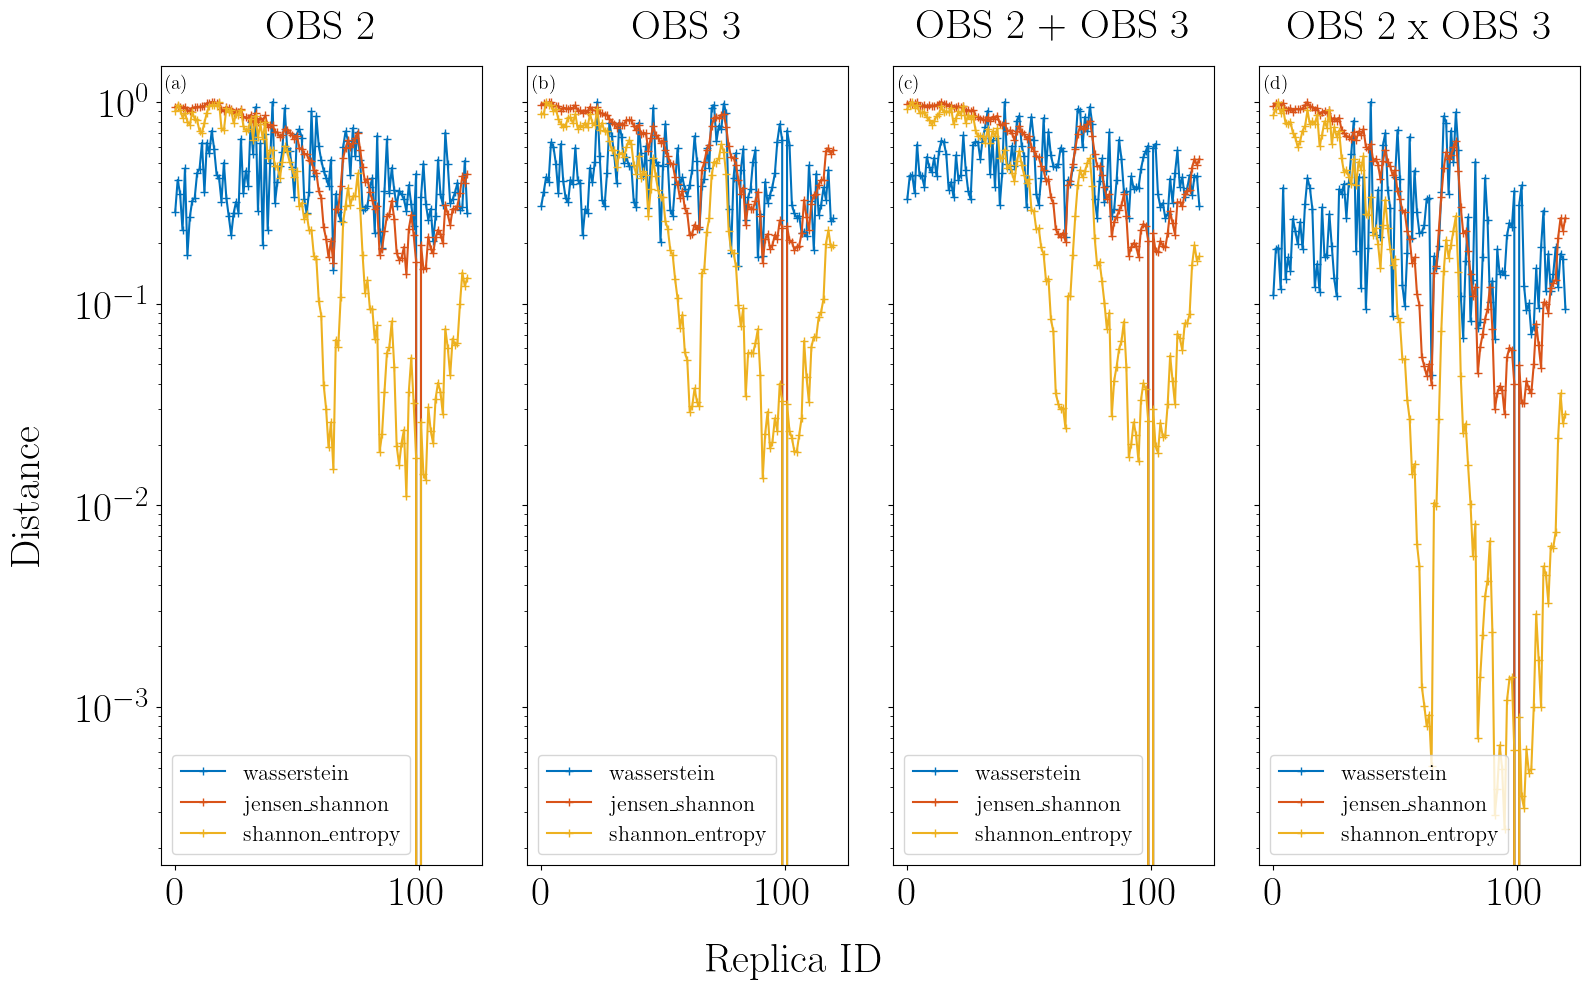

In [28]:
plot_dist_and_combined_dist(
    distance_dict_hist,
    product_distance_dict_hist,
    sum_distance_dict_hist,
    replica_ids=ds.replica_id.values,
)

La combinaison des distances associées à chacun des récepteurs permet d'obtenir des résultats intéressants. Les meilleurs résultats sont obtenus pour l'entropie relative de Shannon en sommant les distances associées à chaque récepteur.

### Distance sur les distributions après KDE 

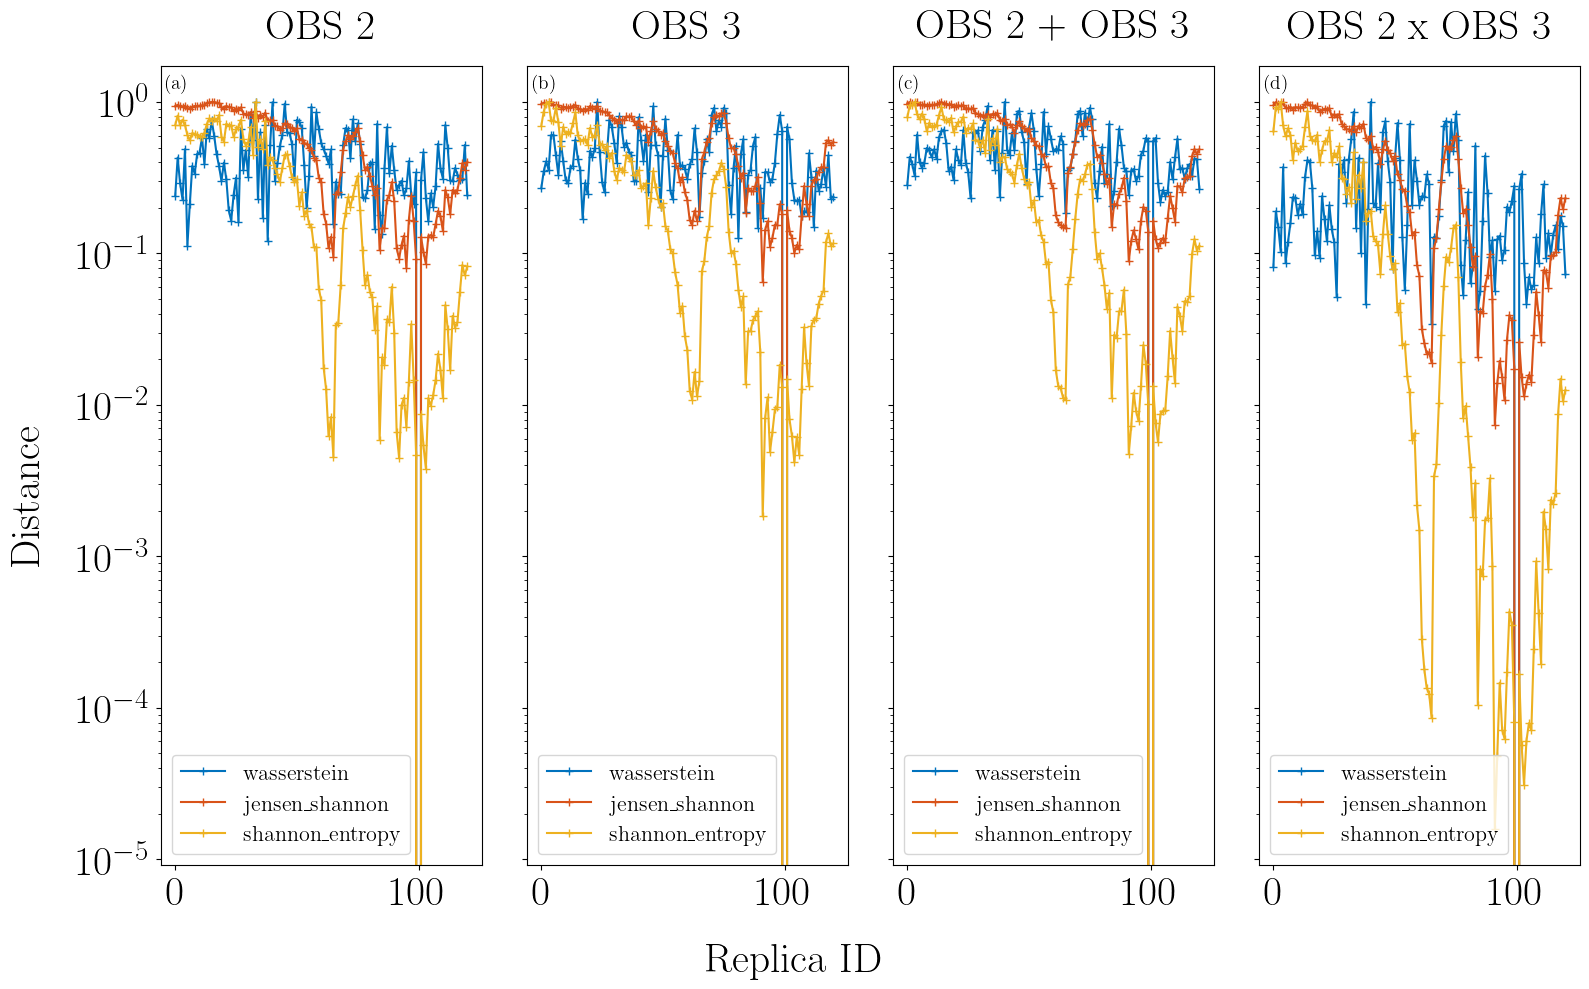

In [29]:
product_distance_dict_kde = get_combine_distance(
    distance_dict=distance_dict_kde, combine_method="product"
)
sum_distance_dict_kde = get_combine_distance(
    distance_dict=distance_dict_kde, combine_method="sum"
)
plot_dist_and_combined_dist(
    distance_dict_kde,
    product_distance_dict_kde,
    sum_distance_dict_kde,
    replica_ids=ds.replica_id.values,
)

## Validation par bootstrap

Afin de généraliser l'analyse faite sur quelques répliques de référence ci-dessus on calcule la matrice de bootstrap $M_S$ associée à l'entropie relative de Shannon combinée utilisée précédemment. 

Cette matrice est définie par : 

$$
    M_{S} = \begin{bmatrix}
        m_{ij}
    \end{bmatrix}_{(i, j) \in [0, {N_{rep}}]}, \quad \text{avec} \quad m_{ij} = \sum_{k=1, k\neq k_{ref}}^{N_{rcv}} S \left ( \mu_i^{(k)}, \mu_j^{(k)} \right ),
$$

où $\mu_i^{(k)}$ est la distribution du module $\lvert \frac{H_k}{H_{ref}} \rvert$ associé à la réplique $i$.


In [30]:
dist_rcv = get_dist_to_rcv(ds=ds)

In [31]:
spatial_dist_mat = build_dist_matrix(ds)

In [32]:
fmin = 200
fmax = 900
n_bins=100
input="histogram"
distances=["wasserstein", "jensen_shannon", "shannon_entropy"]

dist_mat_prod, dist_mat_sum = get_bootstrap_dist_matrix(
    ds,
    distances=distances,
    input=input,
    fmin=fmin,
    fmax=fmax,
    n_bins=n_bins,
)

### Distance de Wassertein

#### Combinaison produit 

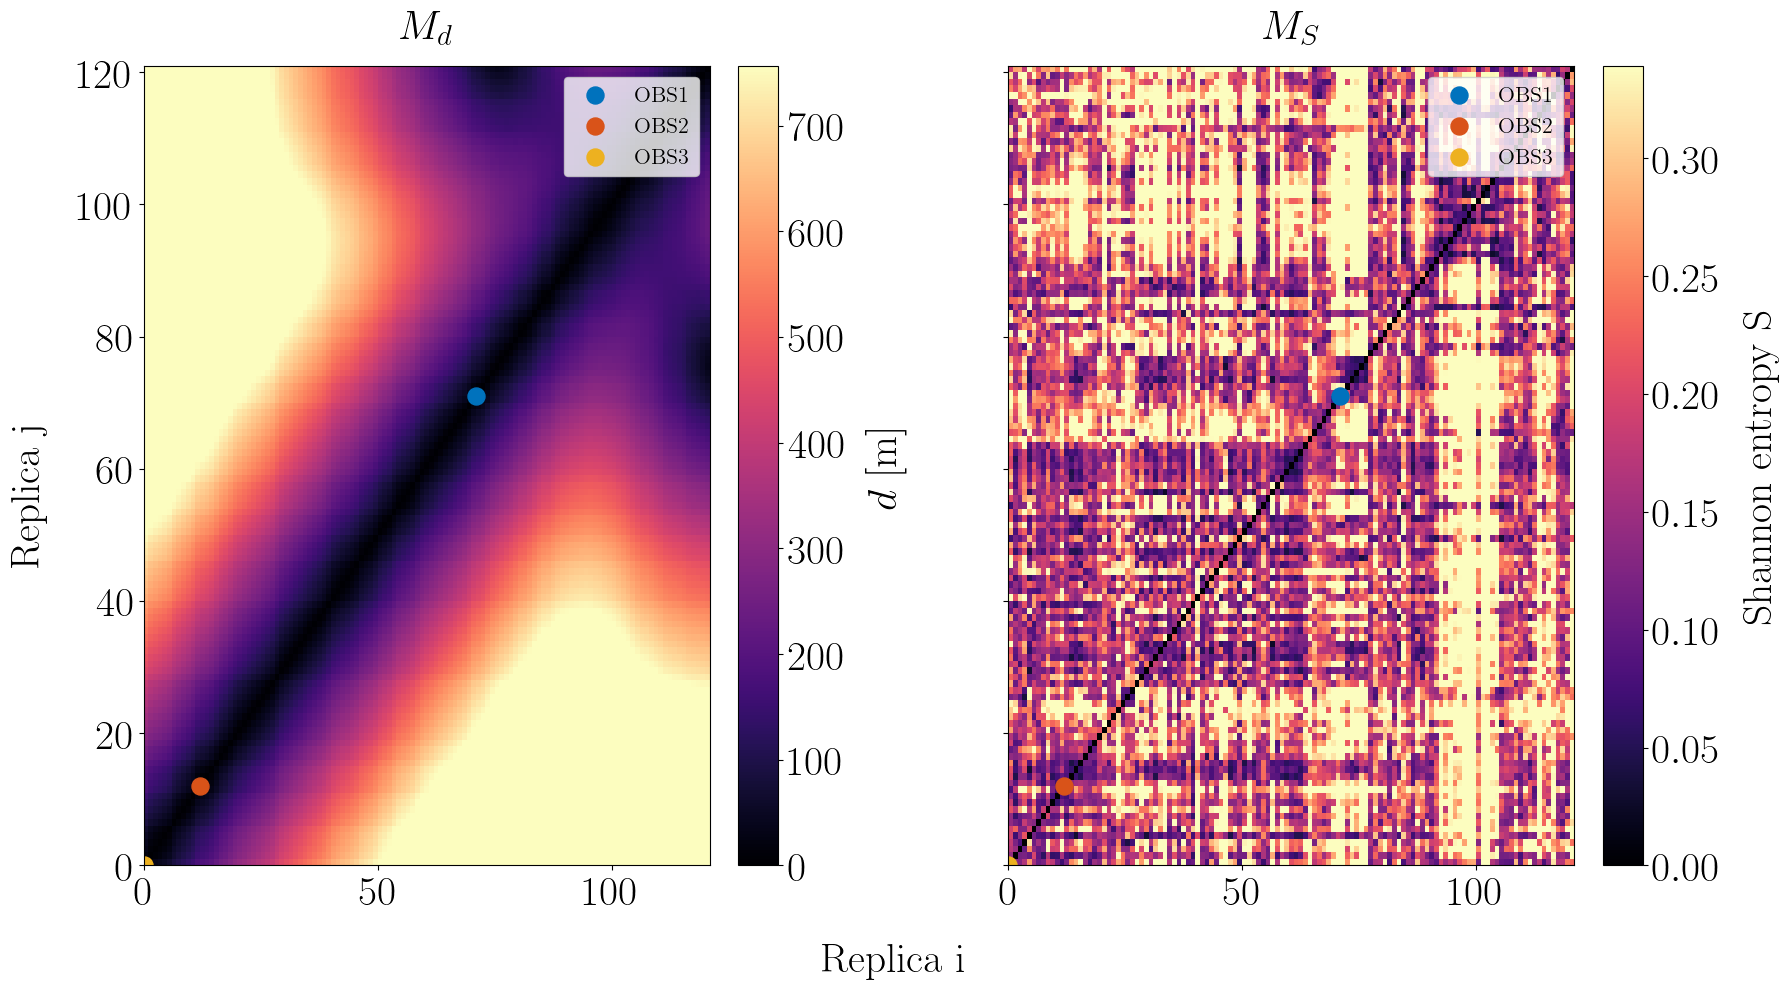

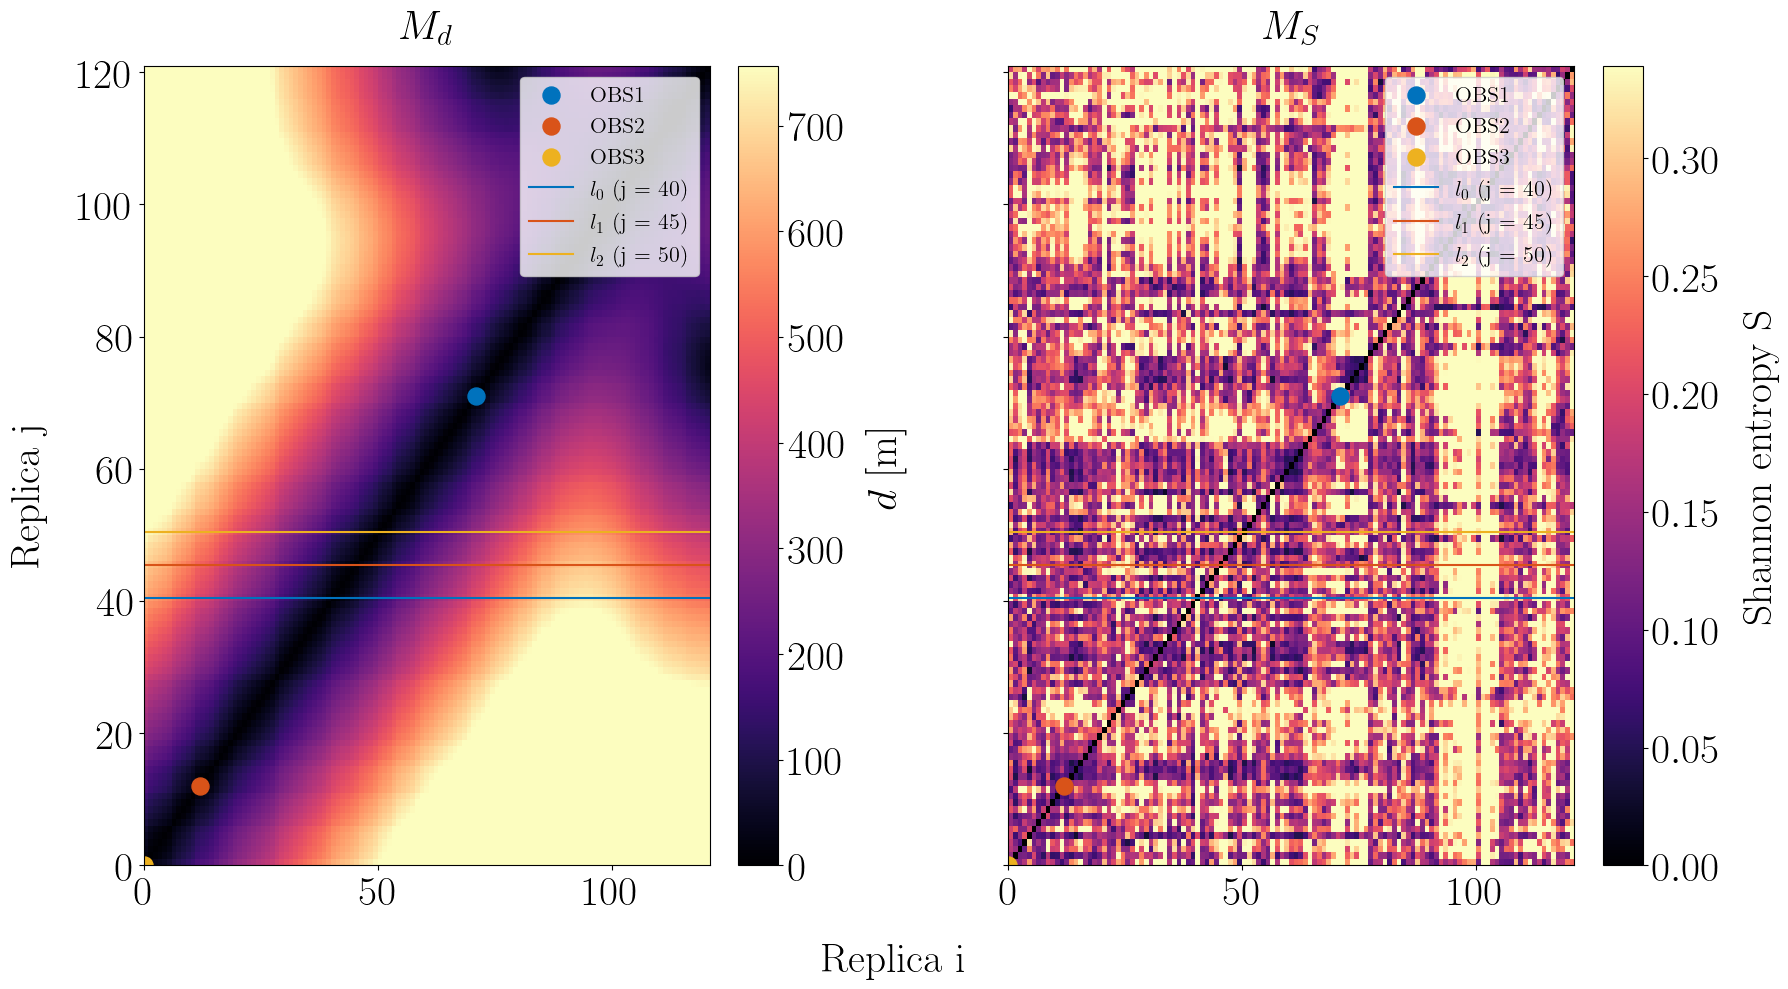

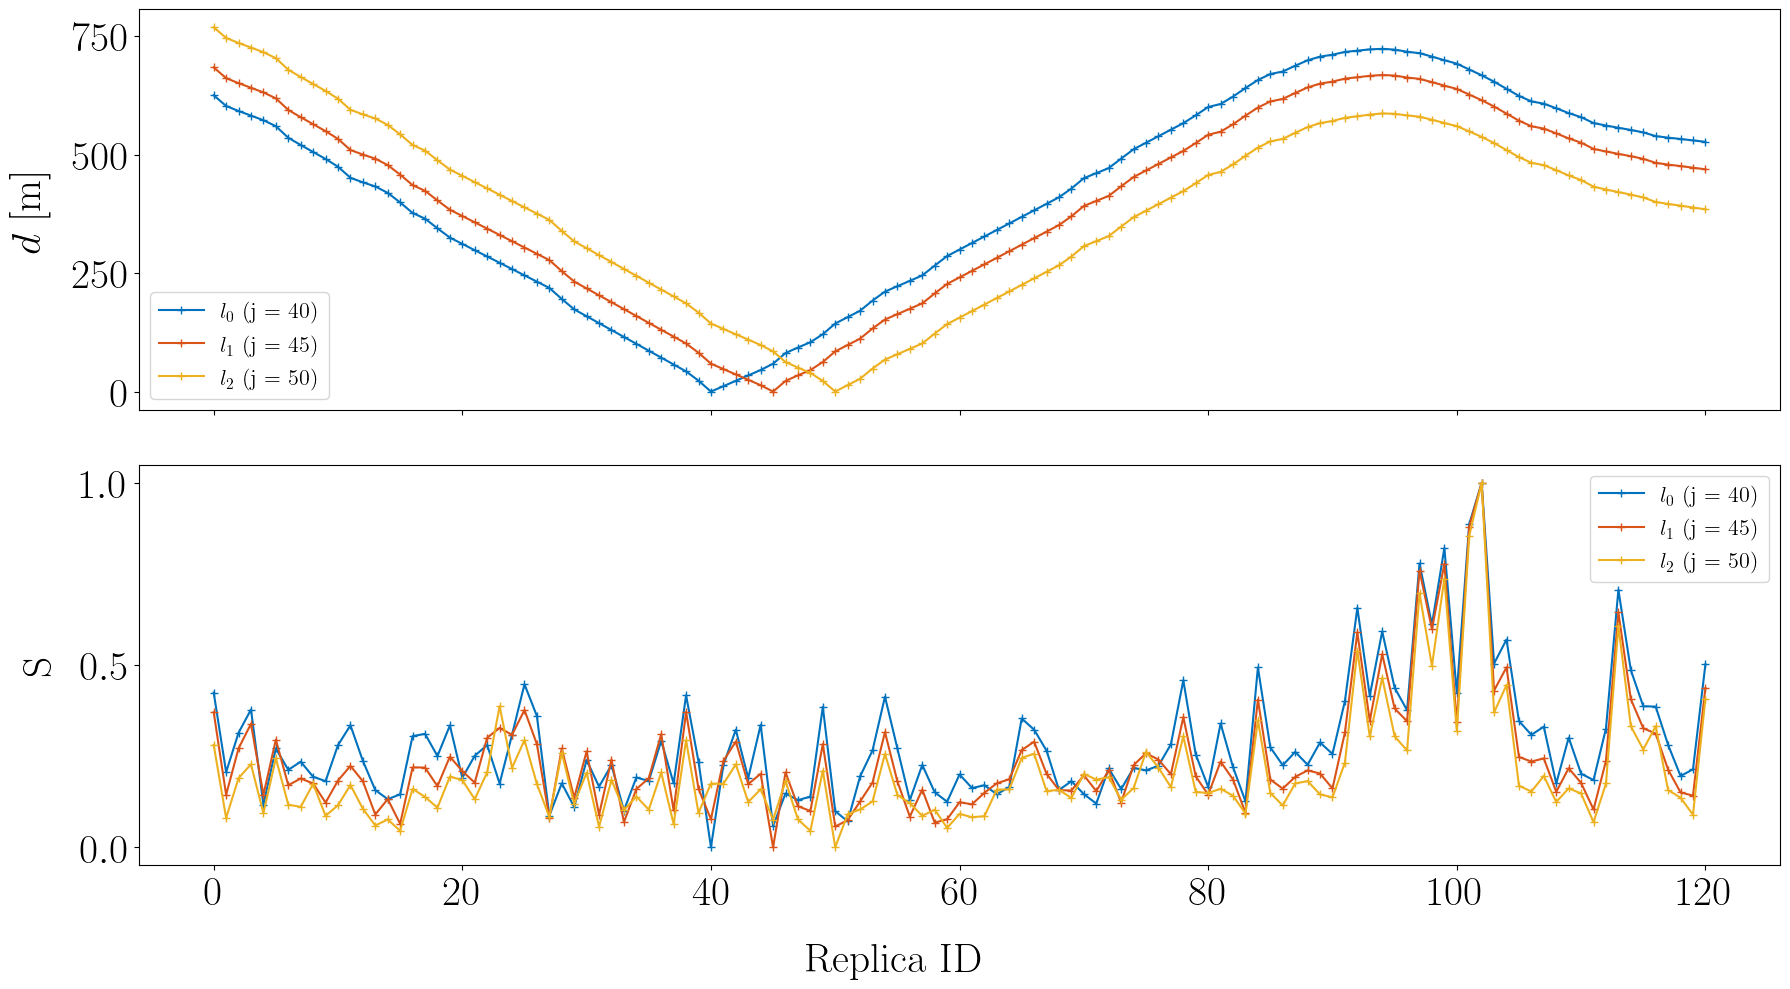

In [33]:
distance = "wasserstein"
rcv_combinaison_strategy = "product"

plot_distance_matrix_comparison(
    spatial_dist_mat=spatial_dist_mat,
    dist_mat=dist_mat_prod[distance],
    fig_folder=fig_folder,
    dist_type=distance,
    rcv_combinaison_strategy=rcv_combinaison_strategy,
    cpa_idx=obs_cpa_idx,
)
selected_lines = [40, 45, 50]
plot_distance_matrix_comparison_line_selected(
    spatial_dist_mat=spatial_dist_mat,
    dist_mat=dist_mat_prod[distance],
    fig_folder=fig_folder,
    dist_type=distance,
    rcv_combinaison_strategy=rcv_combinaison_strategy,
    cpa_idx=obs_cpa_idx,
    selected_lines=selected_lines,
)
plot_distance_selected_lines(
    spatial_dist_mat=spatial_dist_mat,
    dist_mat=dist_mat_prod[distance],
    fig_folder=fig_folder,
    dist_type=distance,
    rcv_combinaison_strategy=rcv_combinaison_strategy,
    selected_lines=selected_lines,
)

#### Combinaison somme

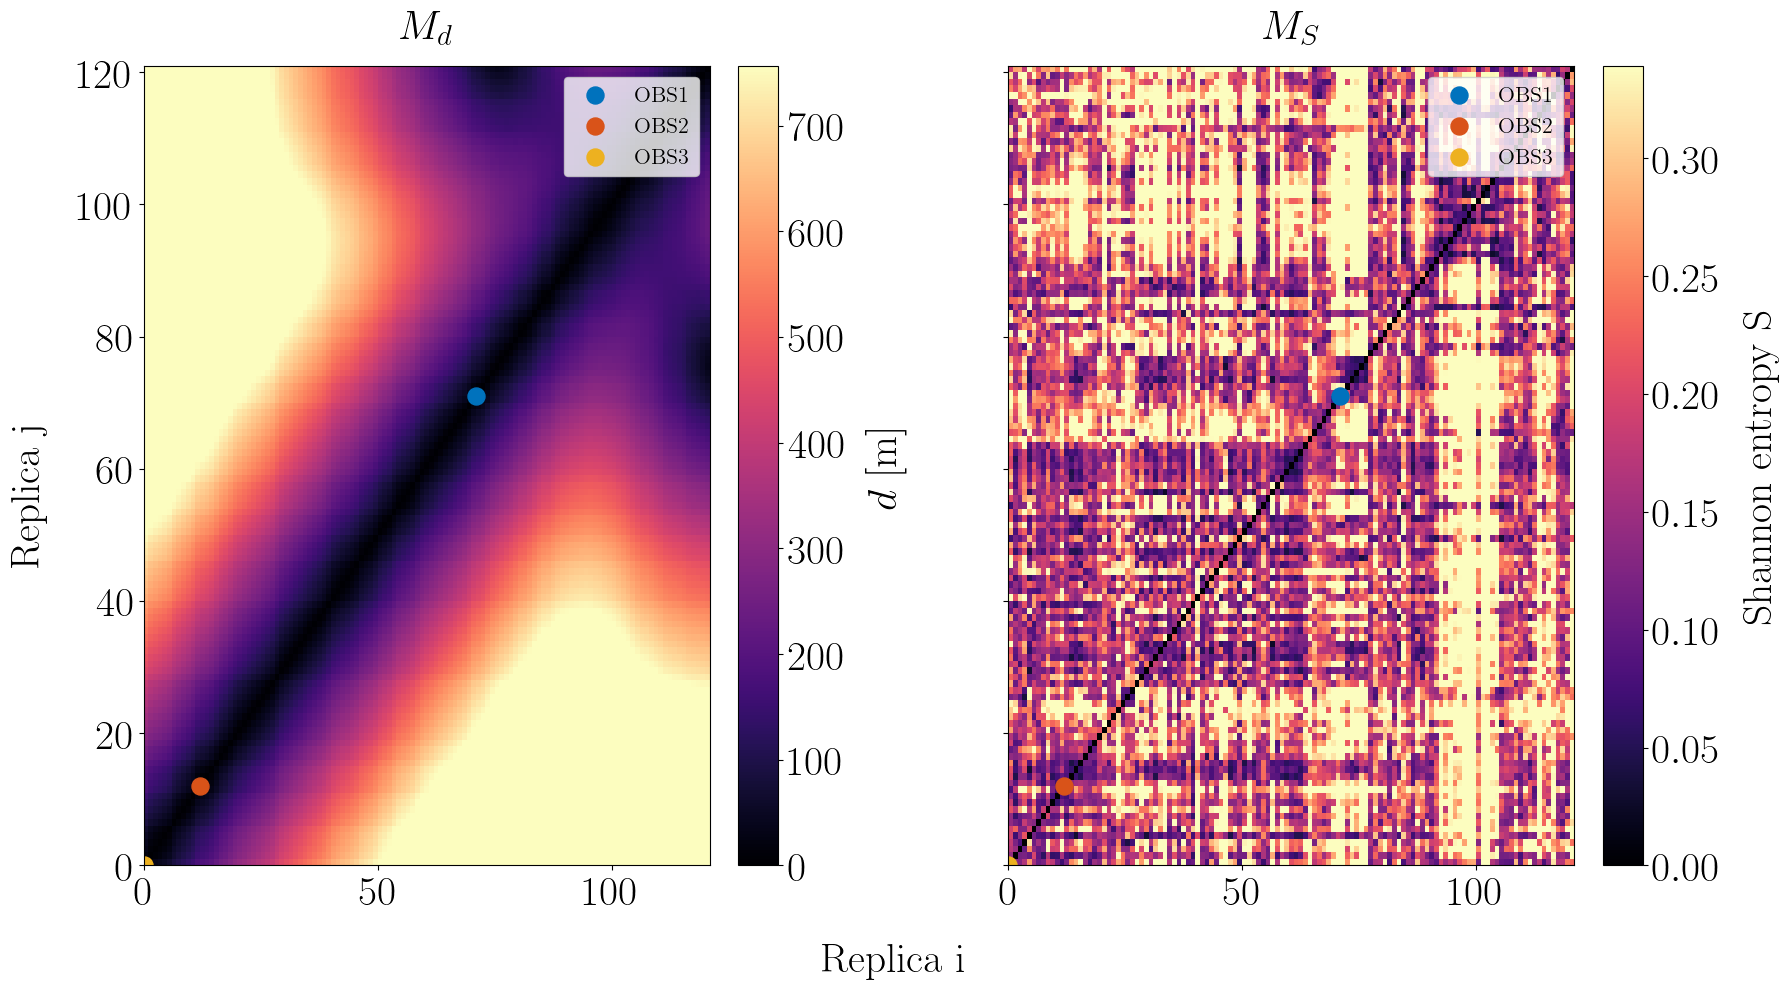

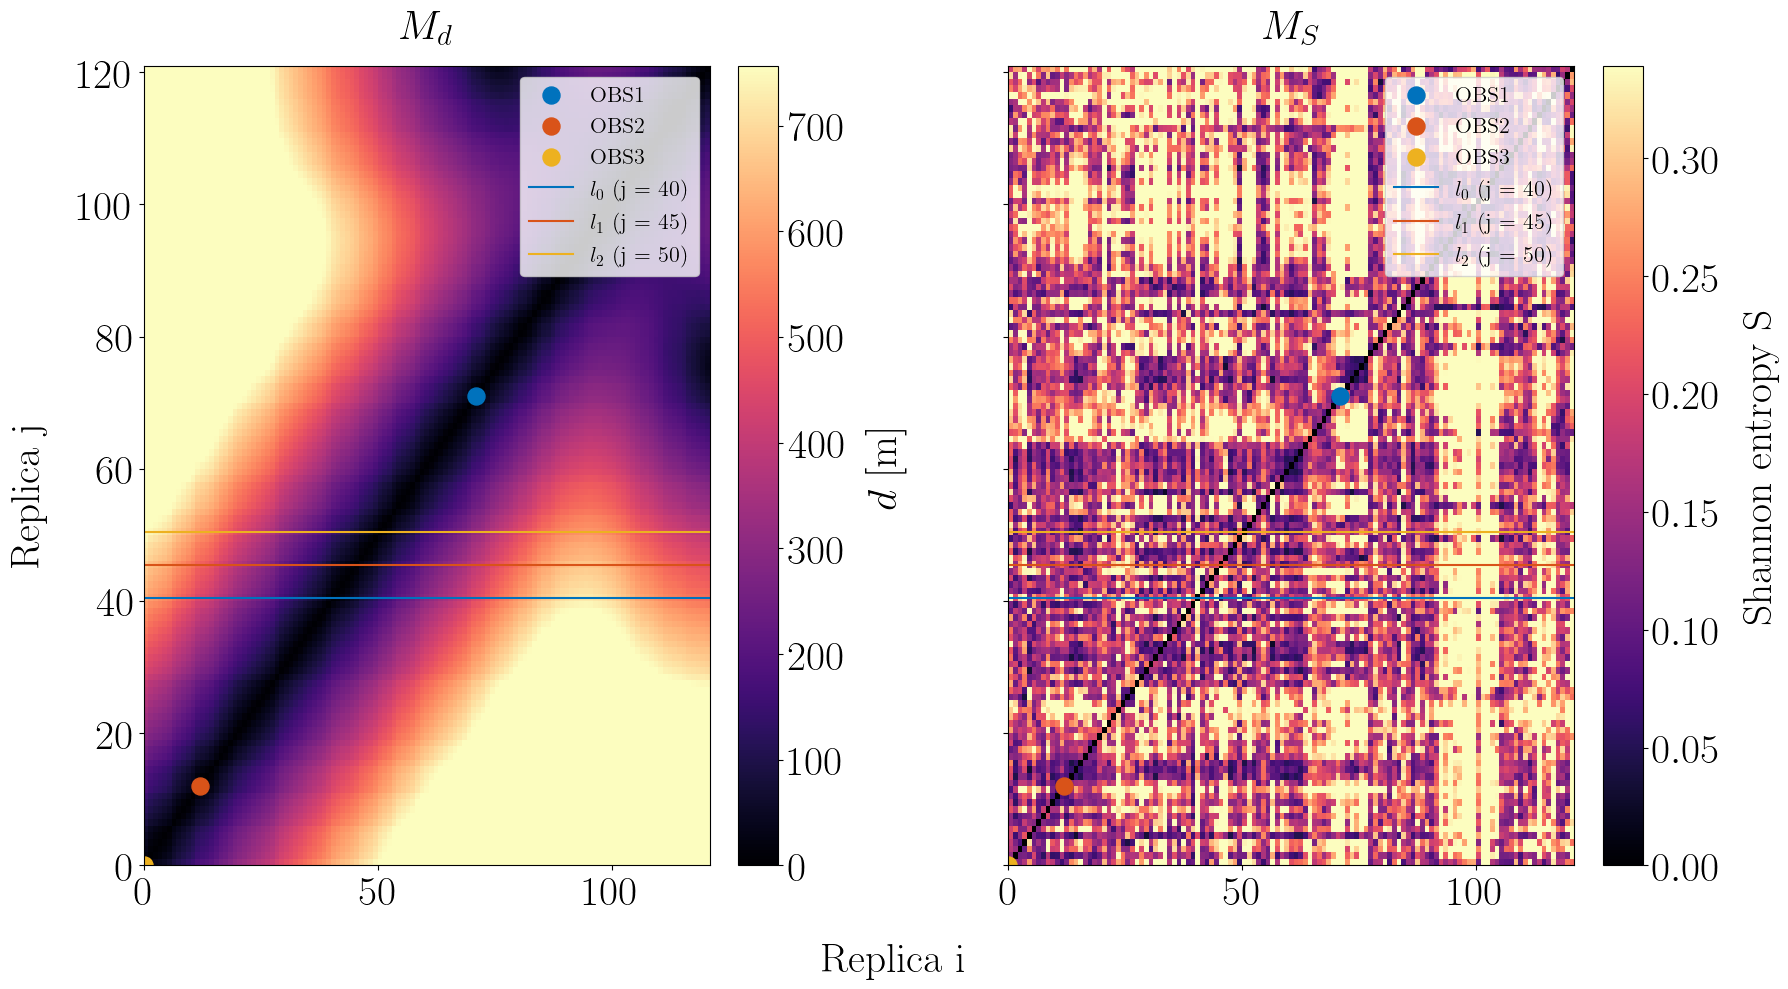

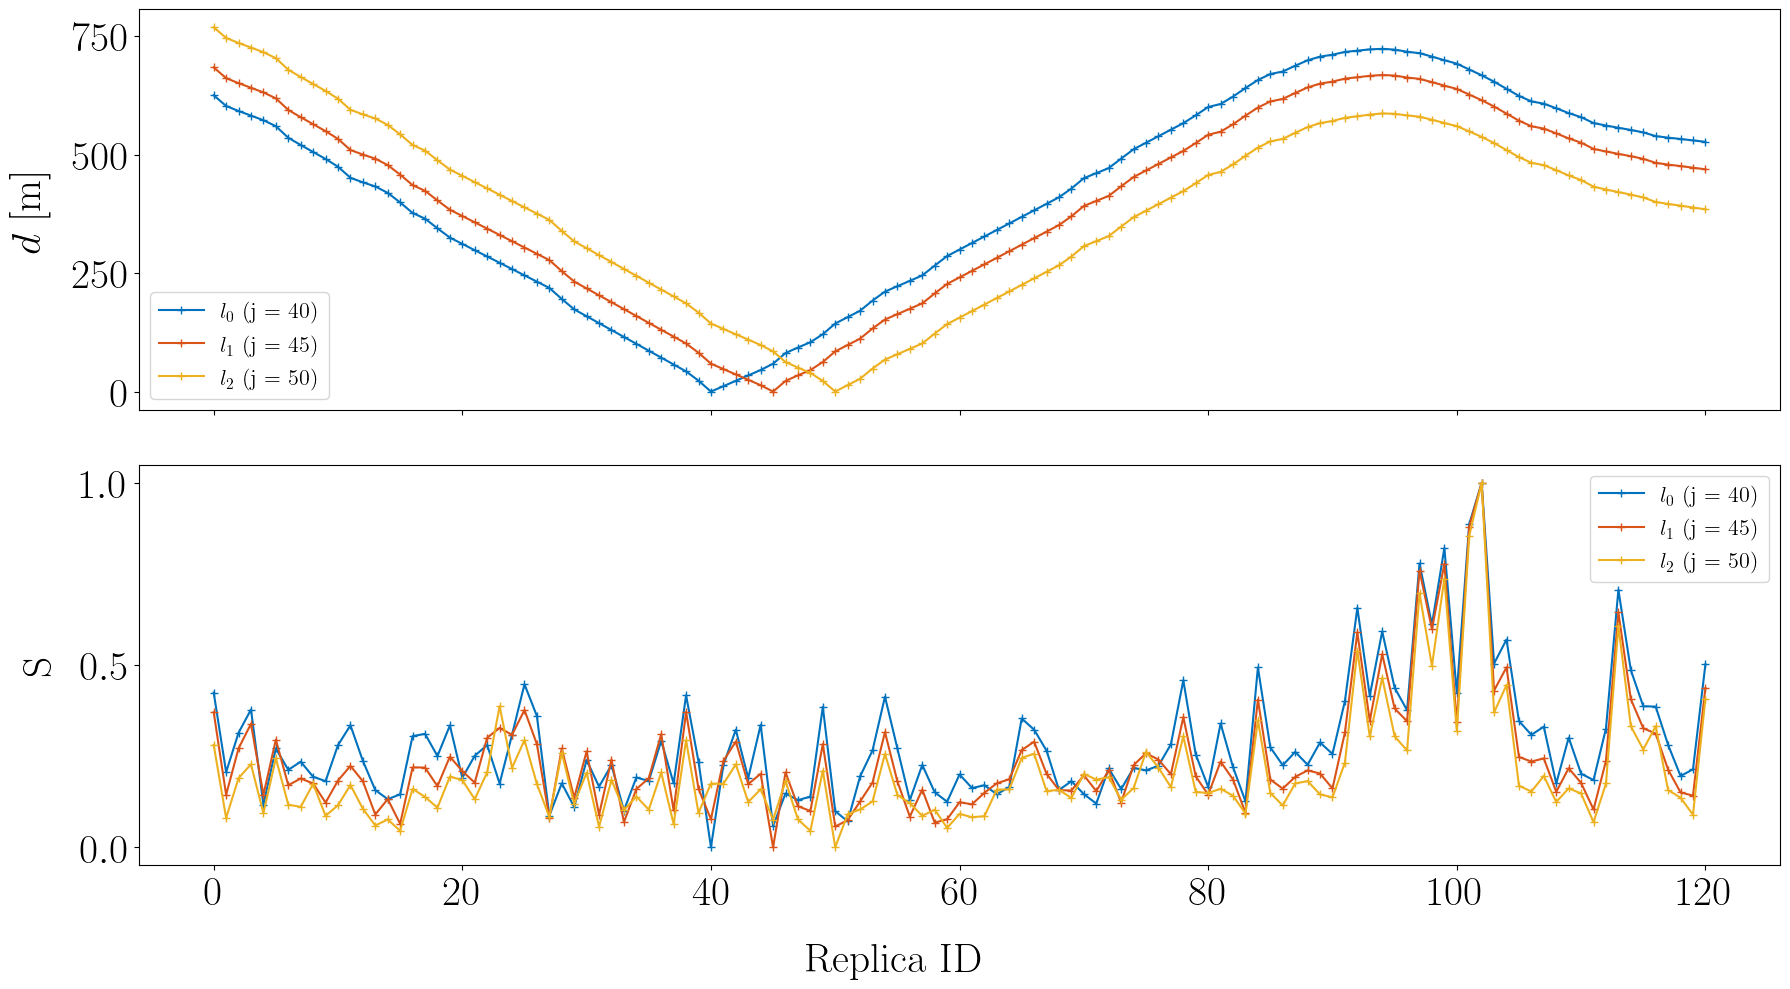

In [34]:
rcv_combinaison_strategy = "sum"

plot_distance_matrix_comparison(
    spatial_dist_mat=spatial_dist_mat,
    dist_mat=dist_mat_prod[distance],
    fig_folder=fig_folder,
    dist_type=distance,
    rcv_combinaison_strategy=rcv_combinaison_strategy,
    cpa_idx=obs_cpa_idx,
)
selected_lines = [40, 45, 50]
plot_distance_matrix_comparison_line_selected(
    spatial_dist_mat=spatial_dist_mat,
    dist_mat=dist_mat_prod[distance],
    fig_folder=fig_folder,
    dist_type=distance,
    rcv_combinaison_strategy=rcv_combinaison_strategy,
    cpa_idx=obs_cpa_idx,
    selected_lines=selected_lines,
)
plot_distance_selected_lines(
    spatial_dist_mat=spatial_dist_mat,
    dist_mat=dist_mat_prod[distance],
    fig_folder=fig_folder,
    dist_type=distance,
    rcv_combinaison_strategy=rcv_combinaison_strategy,
    selected_lines=selected_lines,
)

### Distance de Jensen-Shannon

#### Combinaison produit 

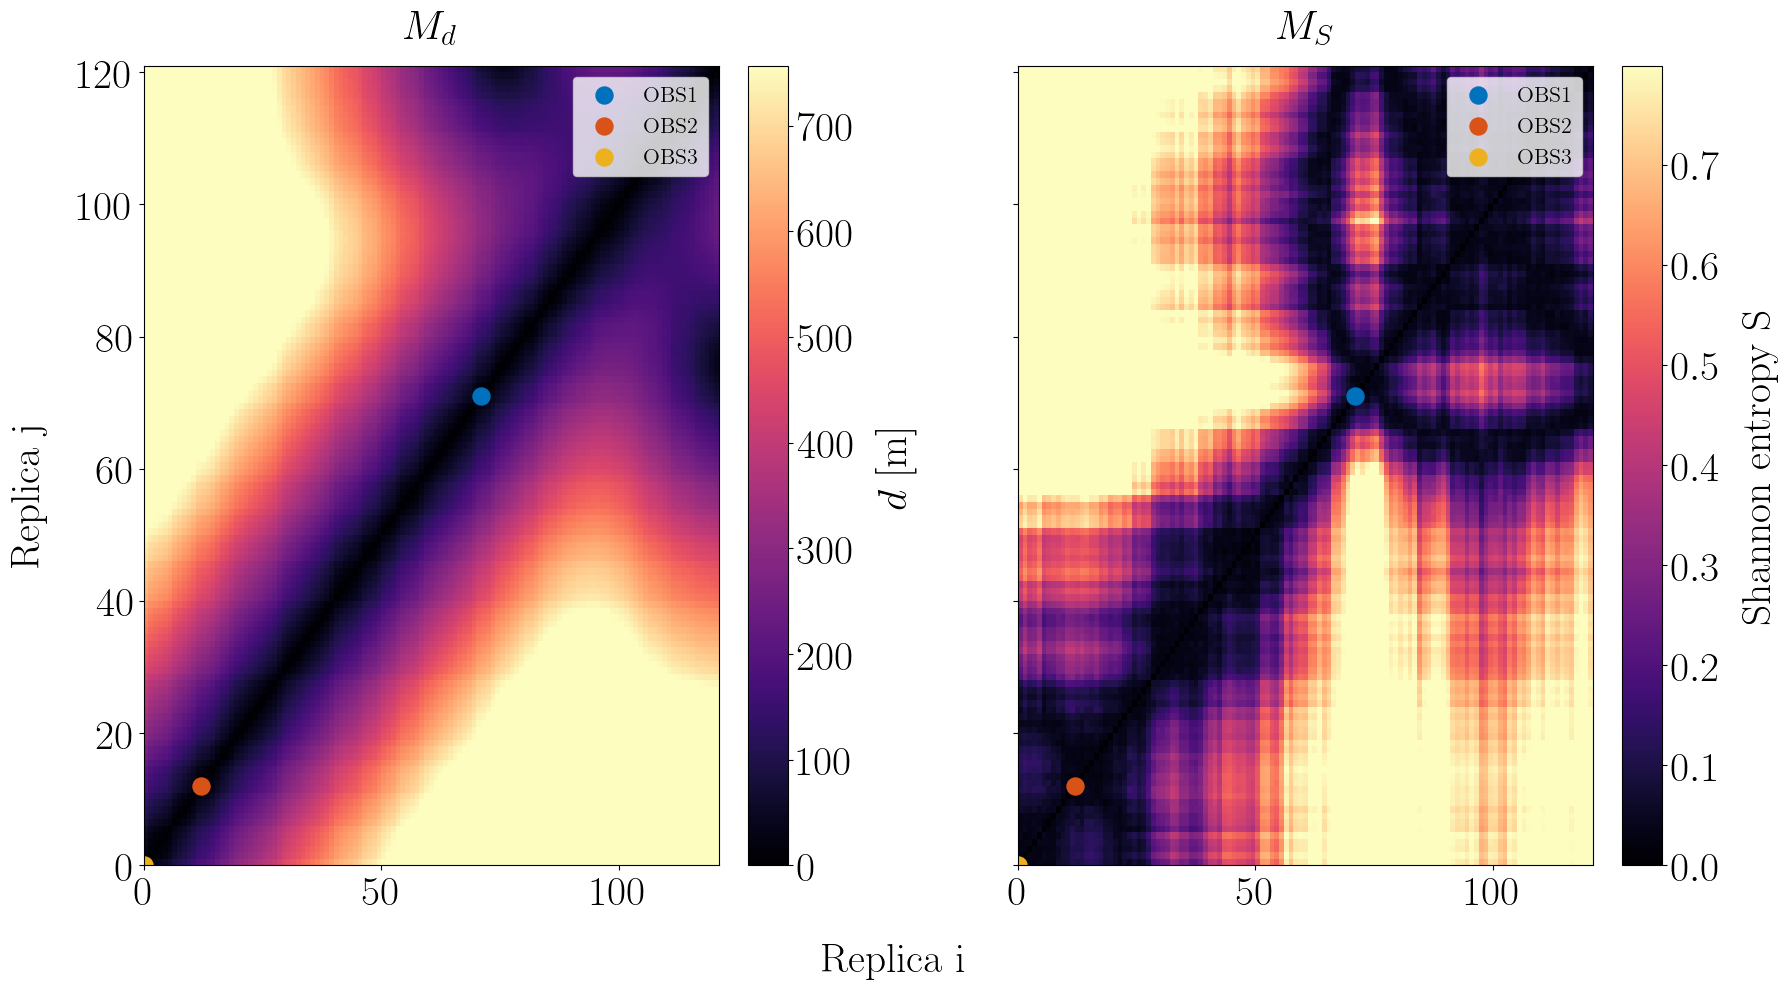

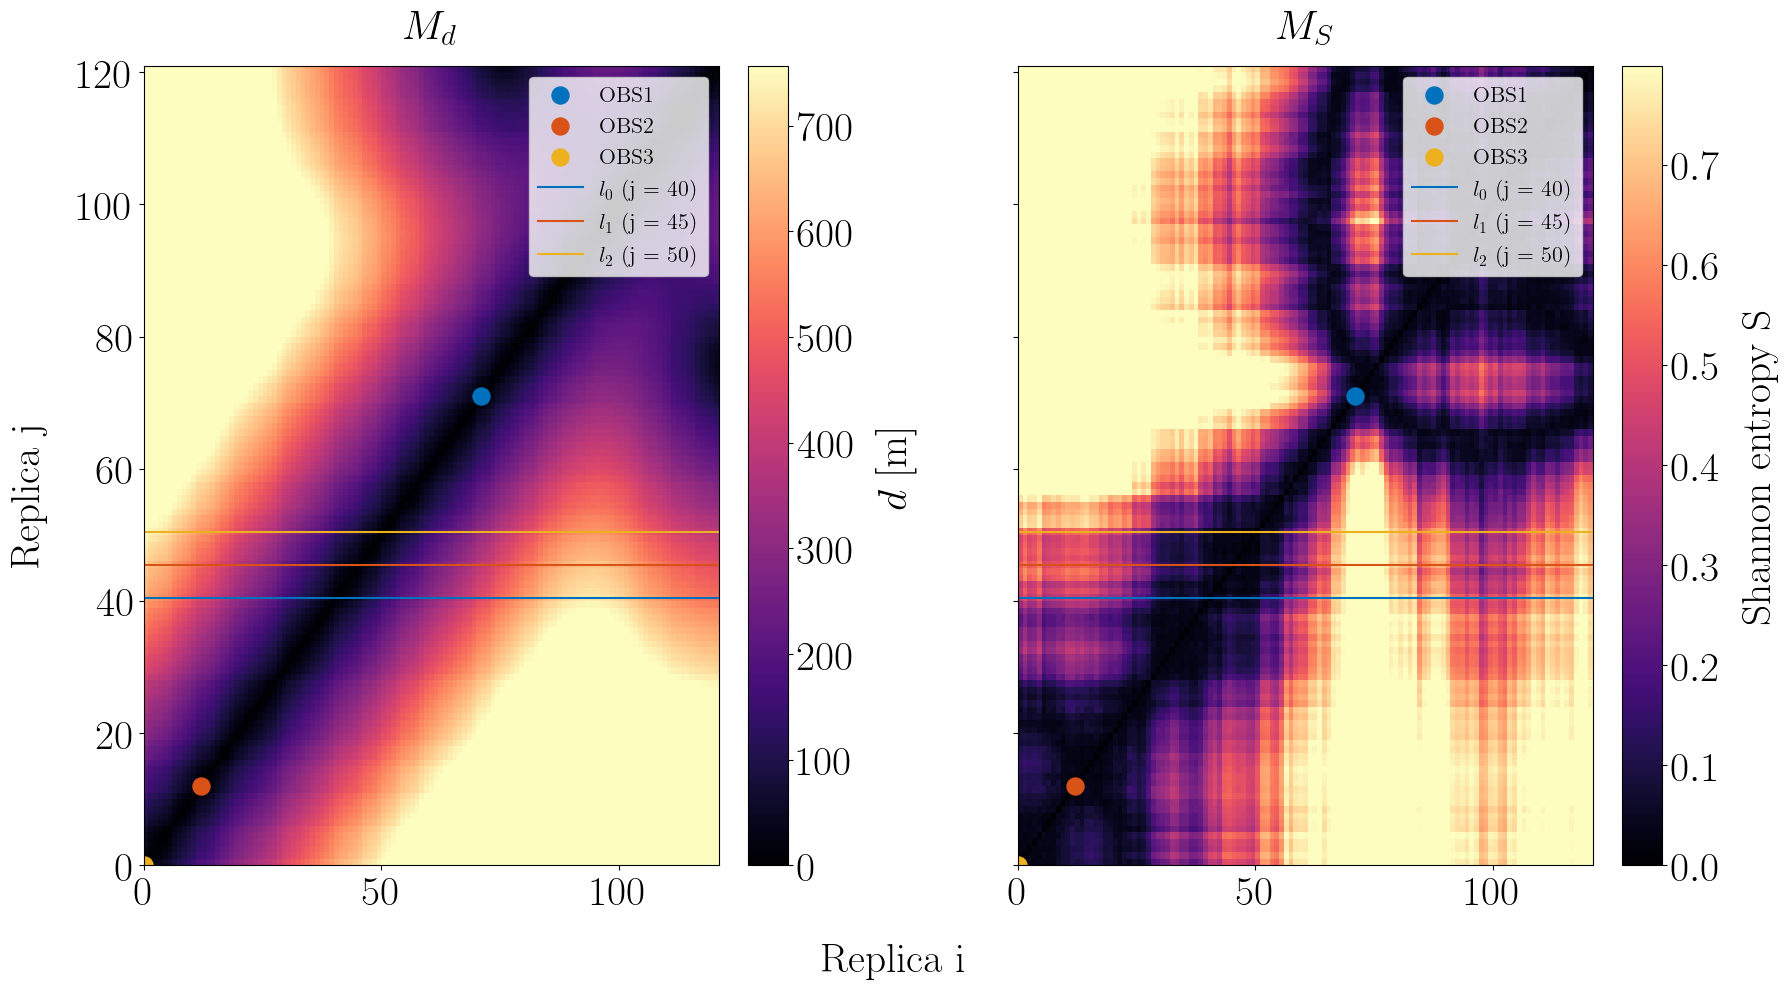

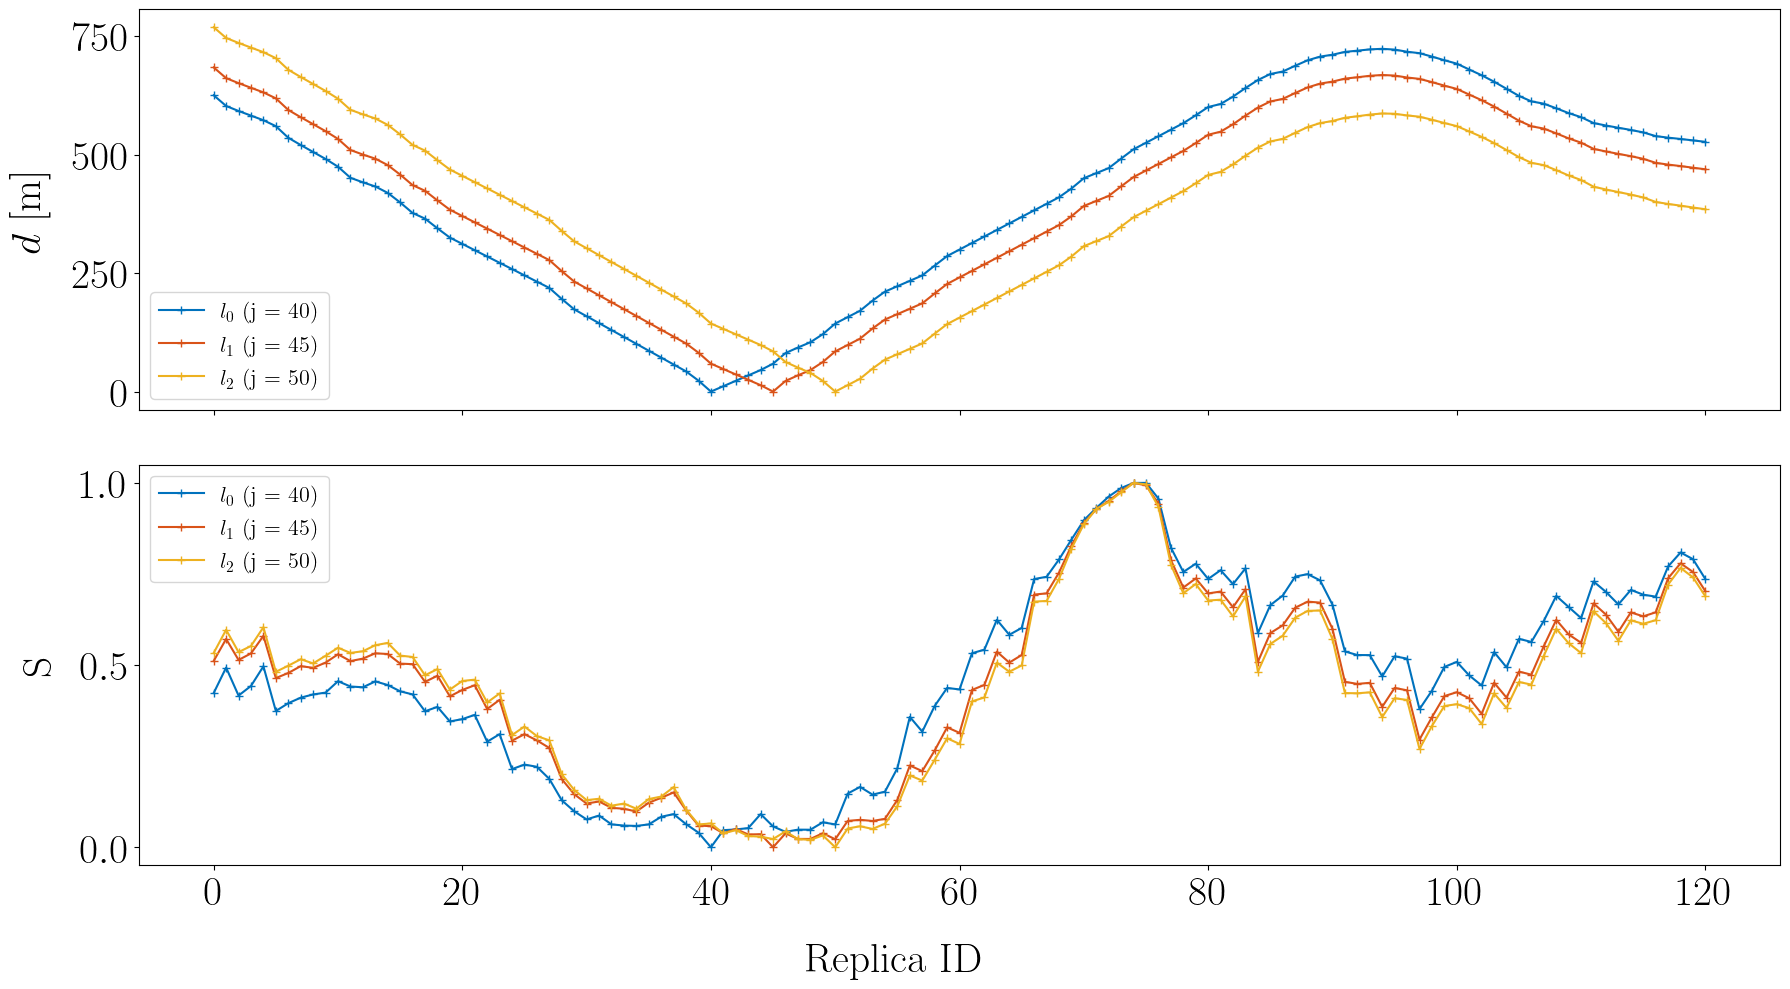

In [ ]:
distance = "jensen_shannon"
rcv_combinaison_strategy = "product"

plot_distance_matrix_comparison(
    spatial_dist_mat=spatial_dist_mat,
    dist_mat=dist_mat_prod[distance],
    fig_folder=fig_folder,
    dist_type=distance,
    rcv_combinaison_strategy=rcv_combinaison_strategy,
    cpa_idx=obs_cpa_idx,
)
selected_lines = [40, 45, 50]
plot_distance_matrix_comparison_line_selected(
    spatial_dist_mat=spatial_dist_mat,
    dist_mat=dist_mat_prod[distance],
    fig_folder=fig_folder,
    dist_type=distance,
    rcv_combinaison_strategy=rcv_combinaison_strategy,
    cpa_idx=obs_cpa_idx,
    selected_lines=selected_lines,
)
plot_distance_selected_lines(
    spatial_dist_mat=spatial_dist_mat,
    dist_mat=dist_mat_prod[distance],
    fig_folder=fig_folder,
    dist_type=distance,
    rcv_combinaison_strategy=rcv_combinaison_strategy,
    selected_lines=selected_lines,
)

#### Combinaison somme

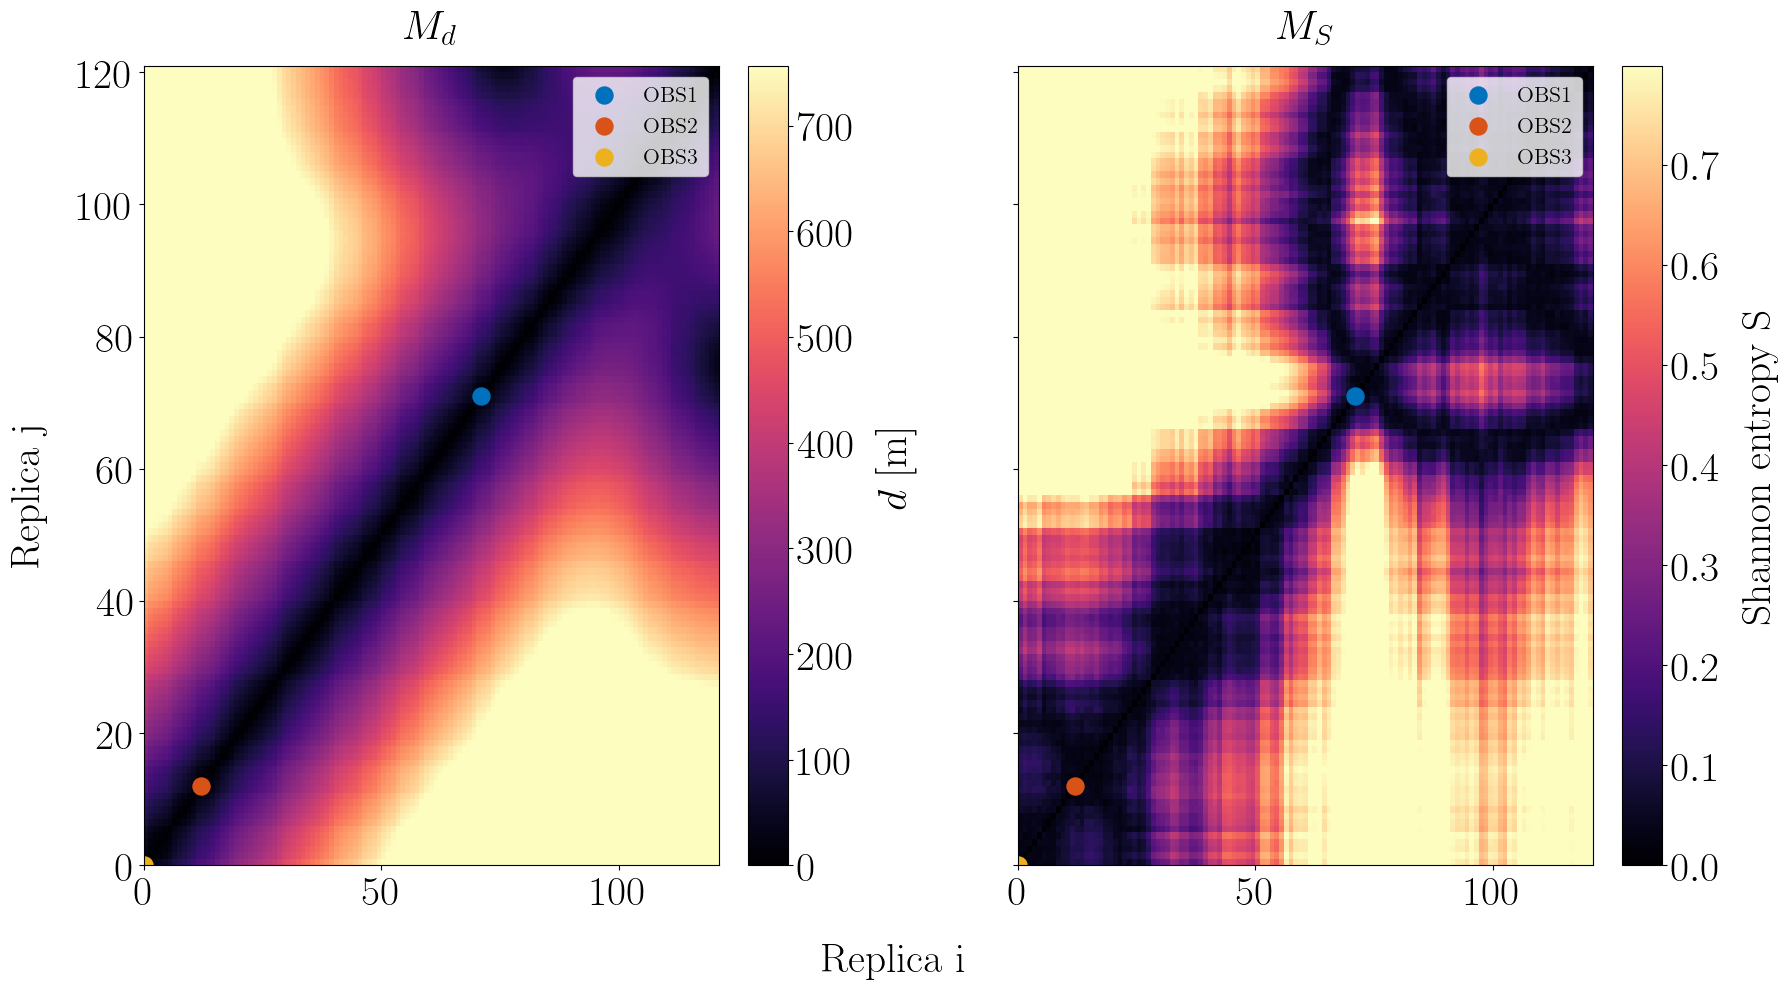

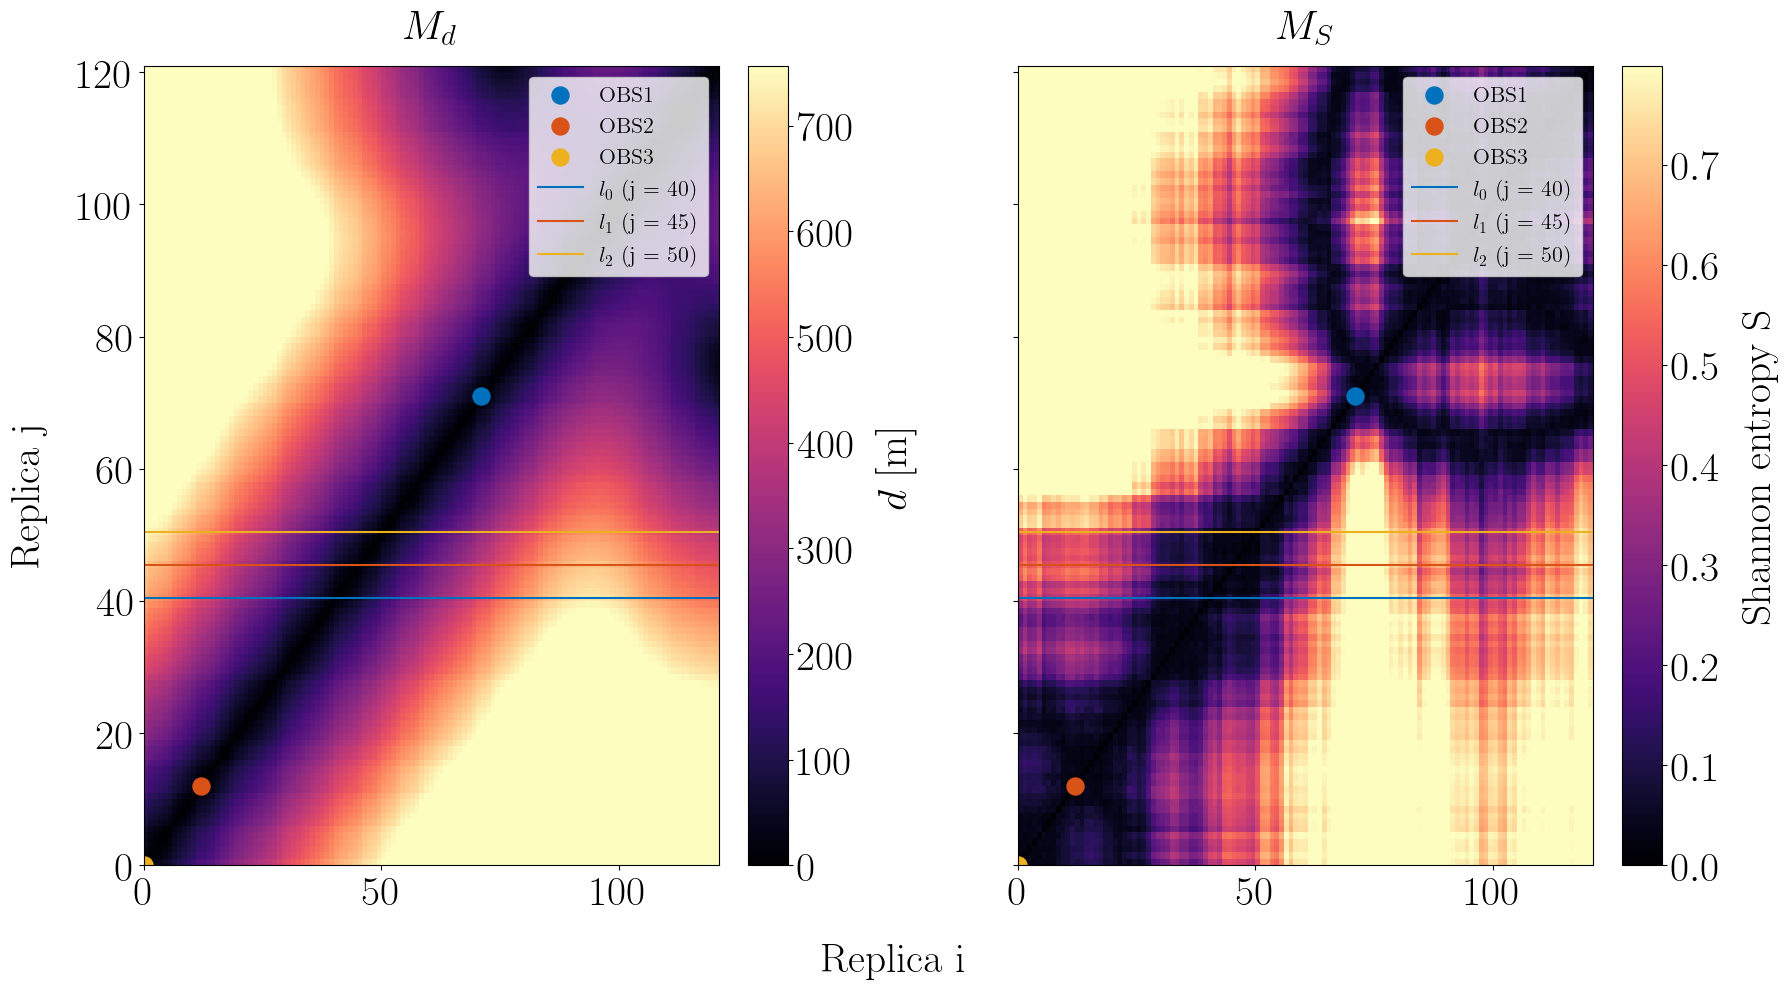

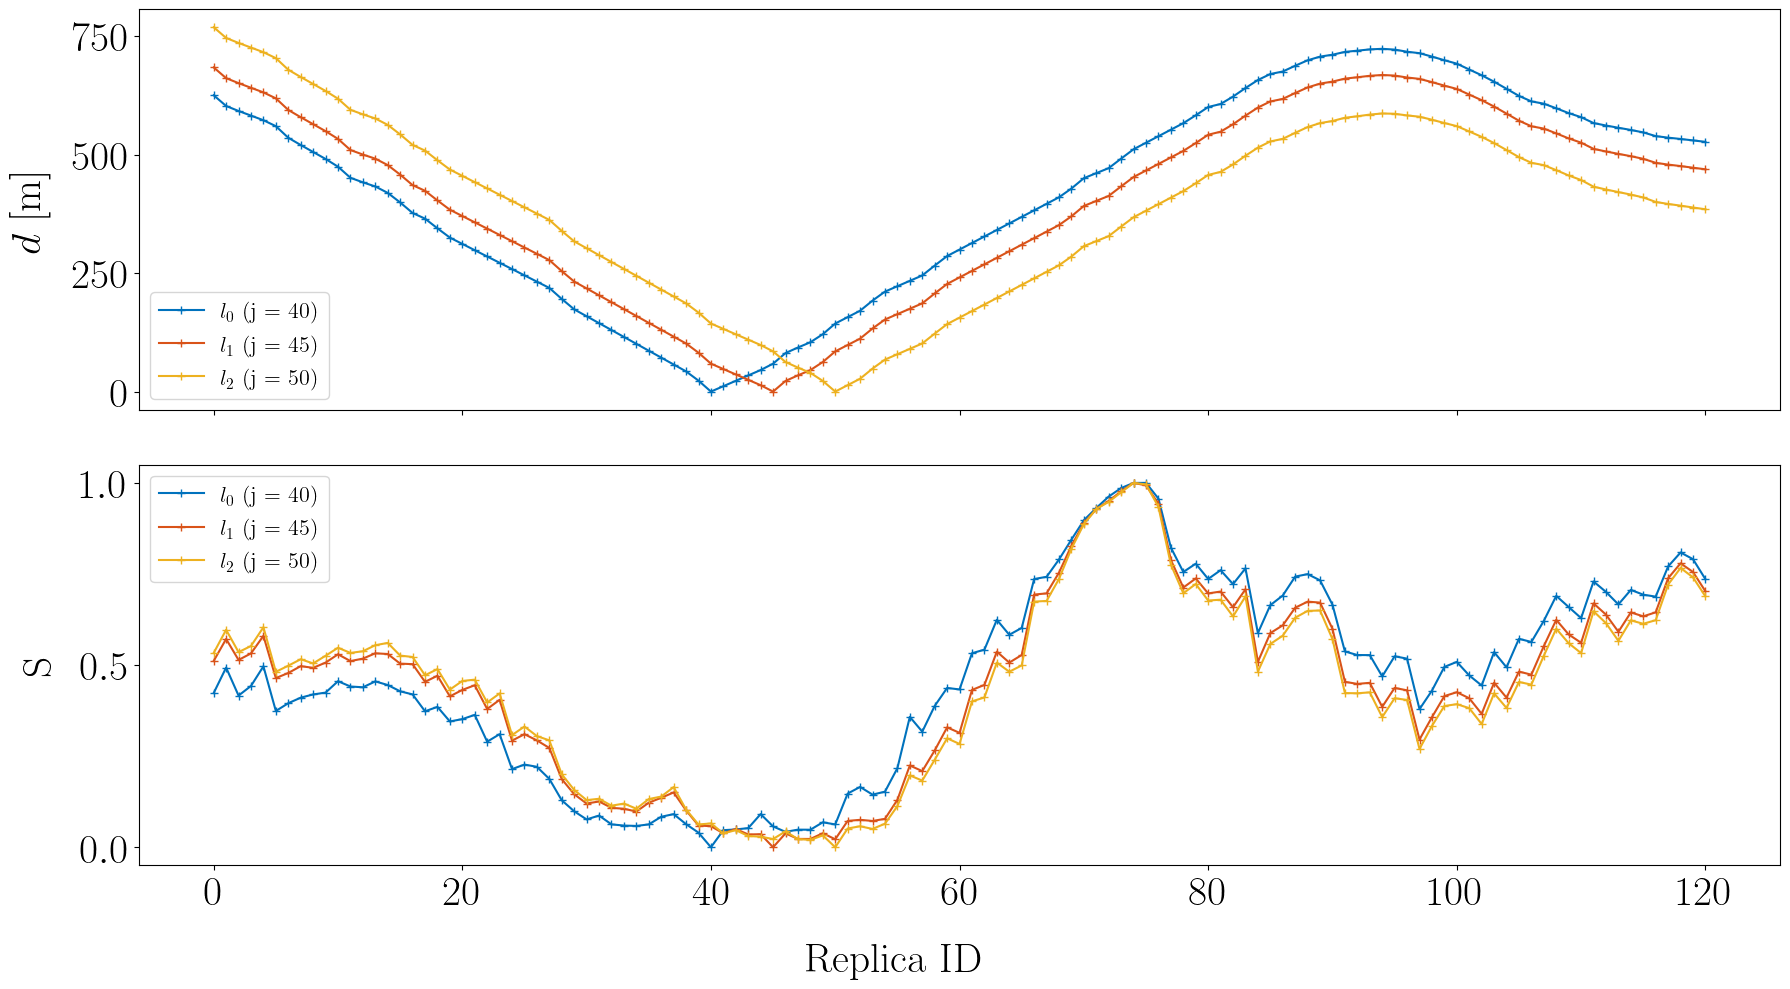

In [ ]:
rcv_combinaison_strategy = "sum"

plot_distance_matrix_comparison(
    spatial_dist_mat=spatial_dist_mat,
    dist_mat=dist_mat_prod[distance],
    fig_folder=fig_folder,
    dist_type=distance,
    rcv_combinaison_strategy=rcv_combinaison_strategy,
    cpa_idx=obs_cpa_idx,
)
selected_lines = [40, 45, 50]
plot_distance_matrix_comparison_line_selected(
    spatial_dist_mat=spatial_dist_mat,
    dist_mat=dist_mat_prod[distance],
    fig_folder=fig_folder,
    dist_type=distance,
    rcv_combinaison_strategy=rcv_combinaison_strategy,
    cpa_idx=obs_cpa_idx,
    selected_lines=selected_lines,
)
plot_distance_selected_lines(
    spatial_dist_mat=spatial_dist_mat,
    dist_mat=dist_mat_prod[distance],
    fig_folder=fig_folder,
    dist_type=distance,
    rcv_combinaison_strategy=rcv_combinaison_strategy,
    selected_lines=selected_lines,
)

### Entropie de Shannon

#### Combinaison produit 

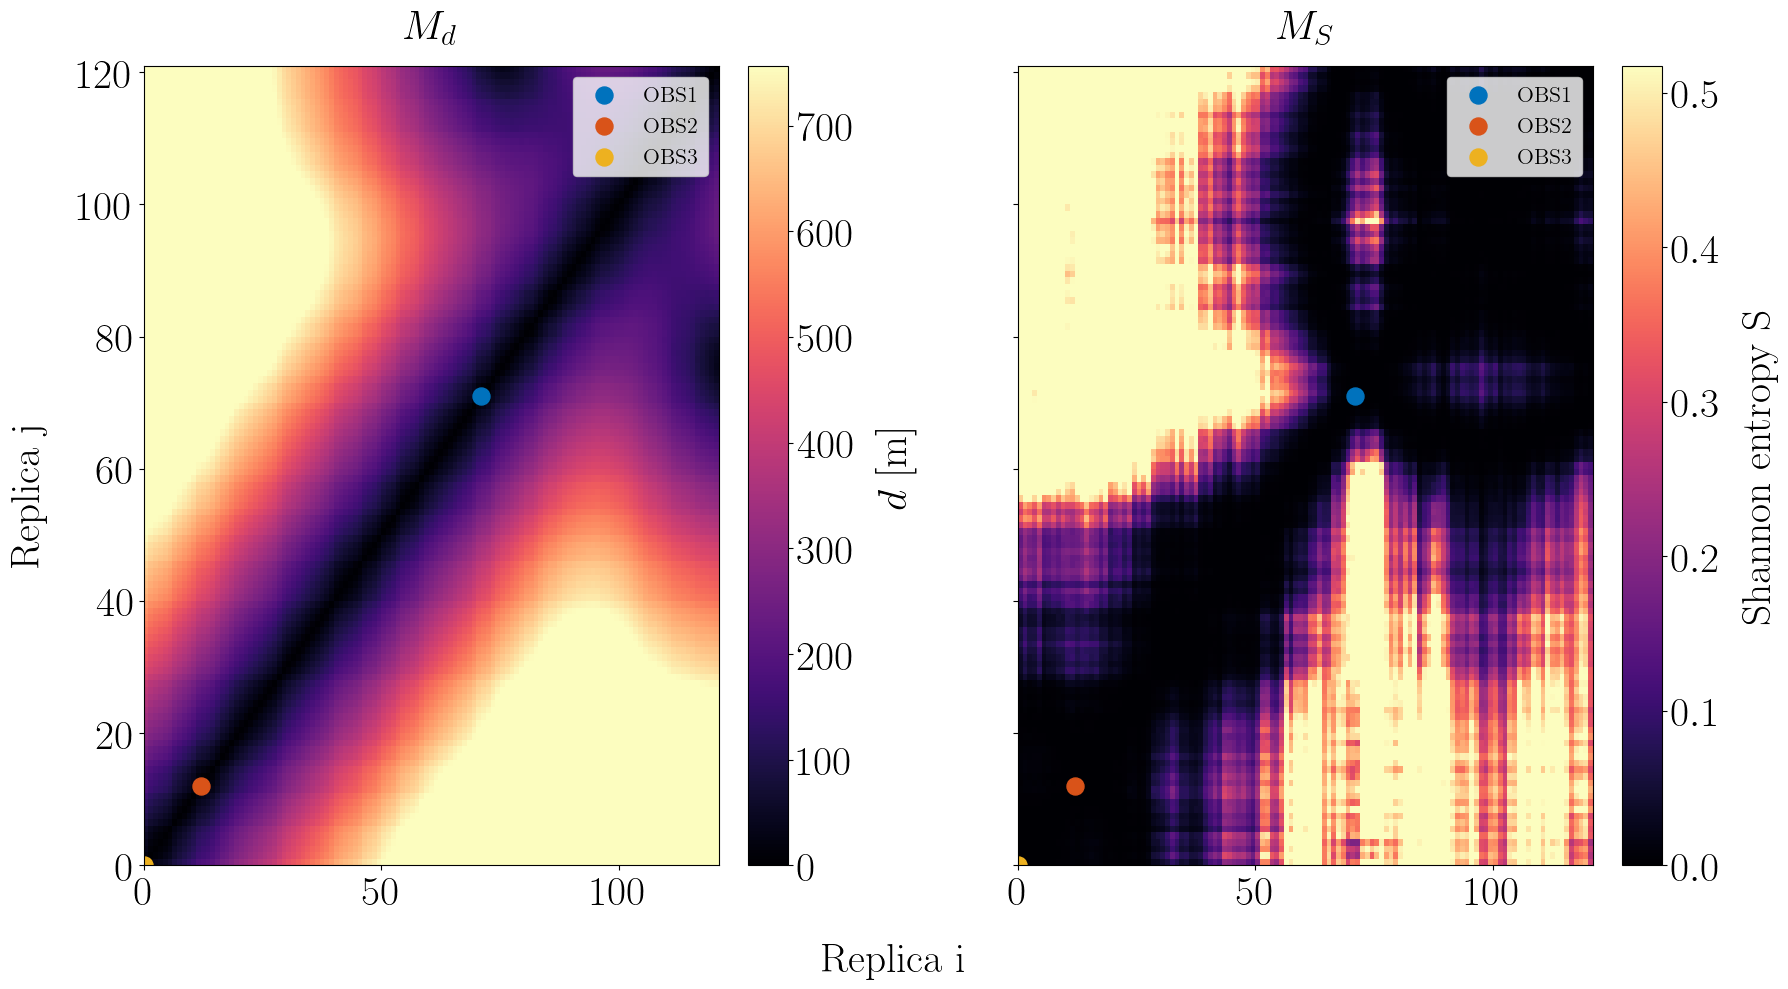

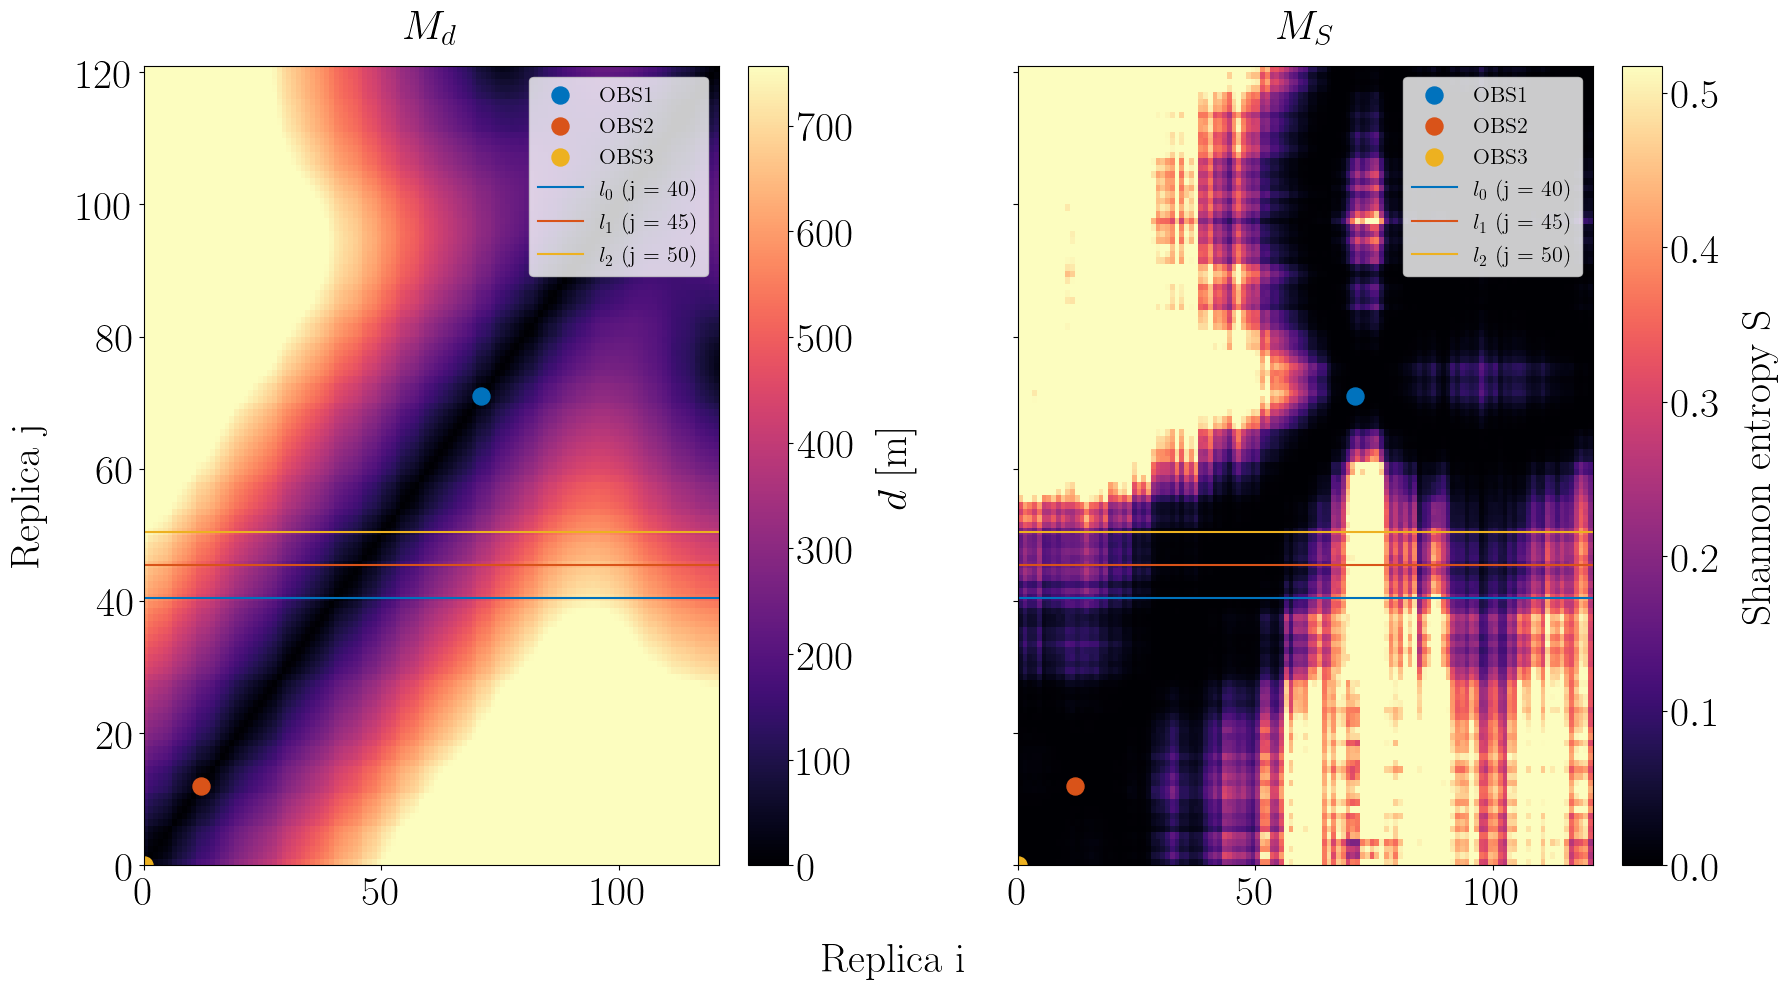

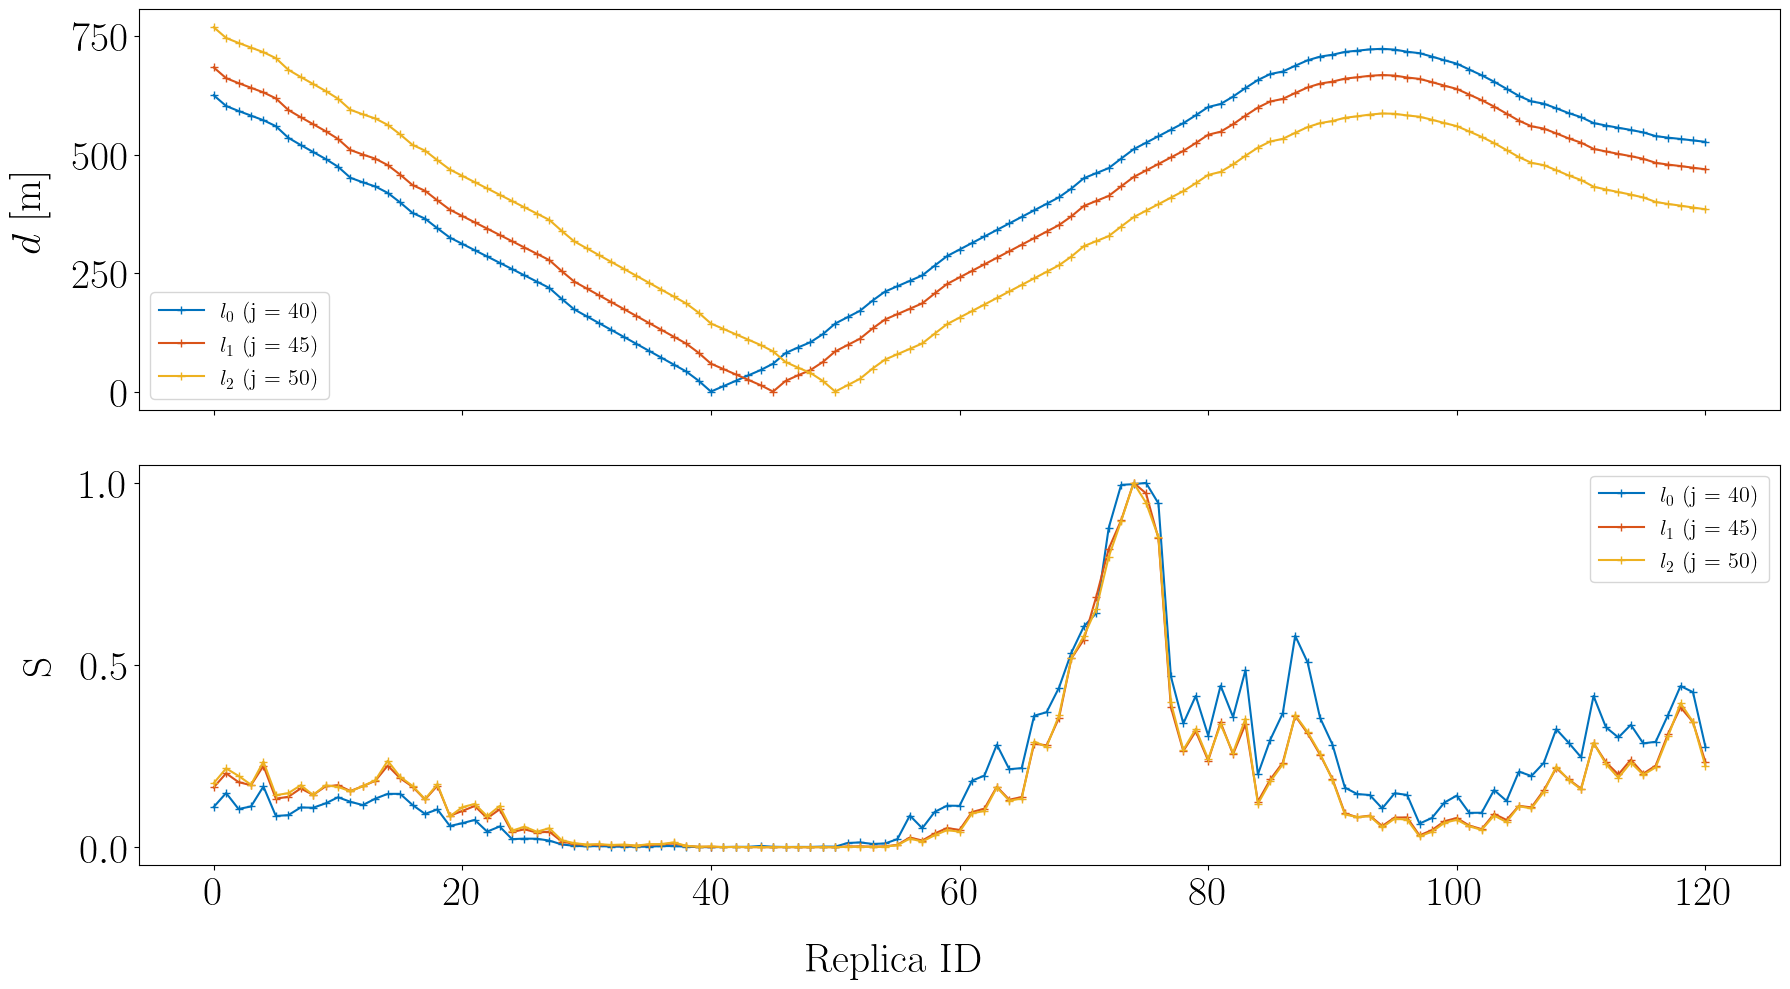

In [37]:
distance = "shannon_entropy"
rcv_combinaison_strategy = "product"

plot_distance_matrix_comparison(
    spatial_dist_mat=spatial_dist_mat,
    dist_mat=dist_mat_prod[distance],
    fig_folder=fig_folder,
    dist_type=distance,
    rcv_combinaison_strategy=rcv_combinaison_strategy,
    cpa_idx=obs_cpa_idx,
)
selected_lines = [40, 45, 50]
plot_distance_matrix_comparison_line_selected(
    spatial_dist_mat=spatial_dist_mat,
    dist_mat=dist_mat_prod[distance],
    fig_folder=fig_folder,
    dist_type=distance,
    rcv_combinaison_strategy=rcv_combinaison_strategy,
    cpa_idx=obs_cpa_idx,
    selected_lines=selected_lines,
)
plot_distance_selected_lines(
    spatial_dist_mat=spatial_dist_mat,
    dist_mat=dist_mat_prod[distance],
    fig_folder=fig_folder,
    dist_type=distance,
    rcv_combinaison_strategy=rcv_combinaison_strategy,
    selected_lines=selected_lines,
)

#### Combinaison somme

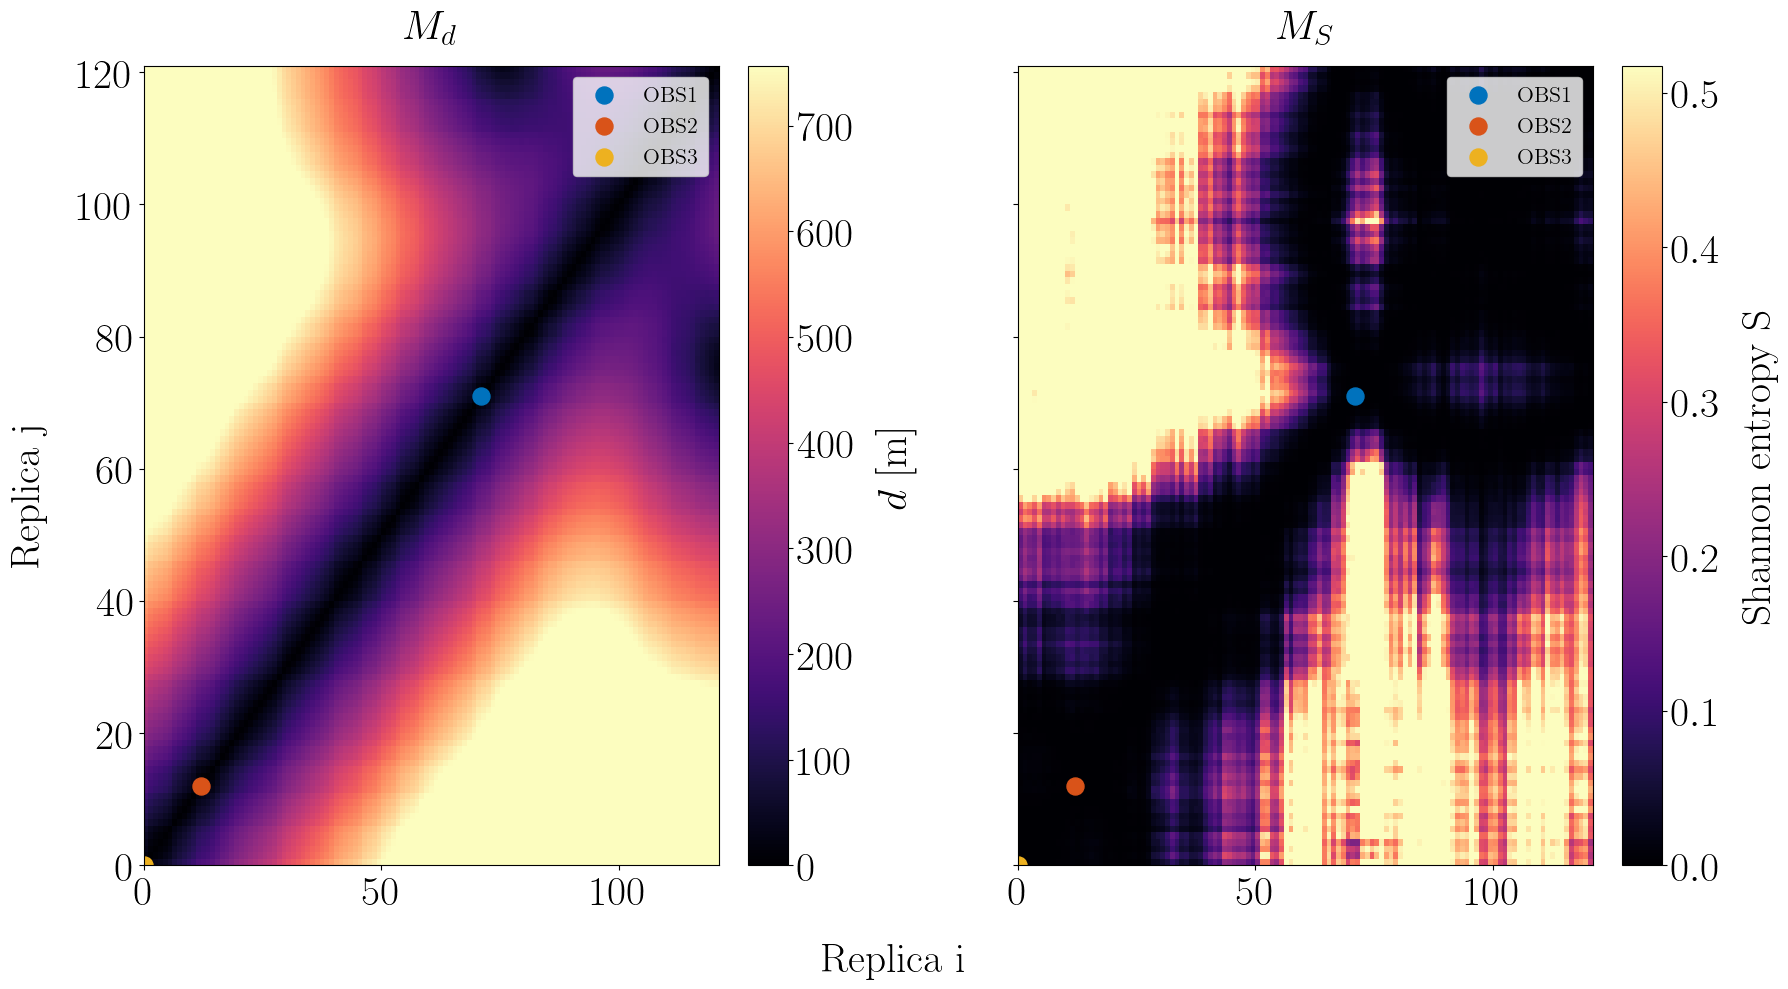

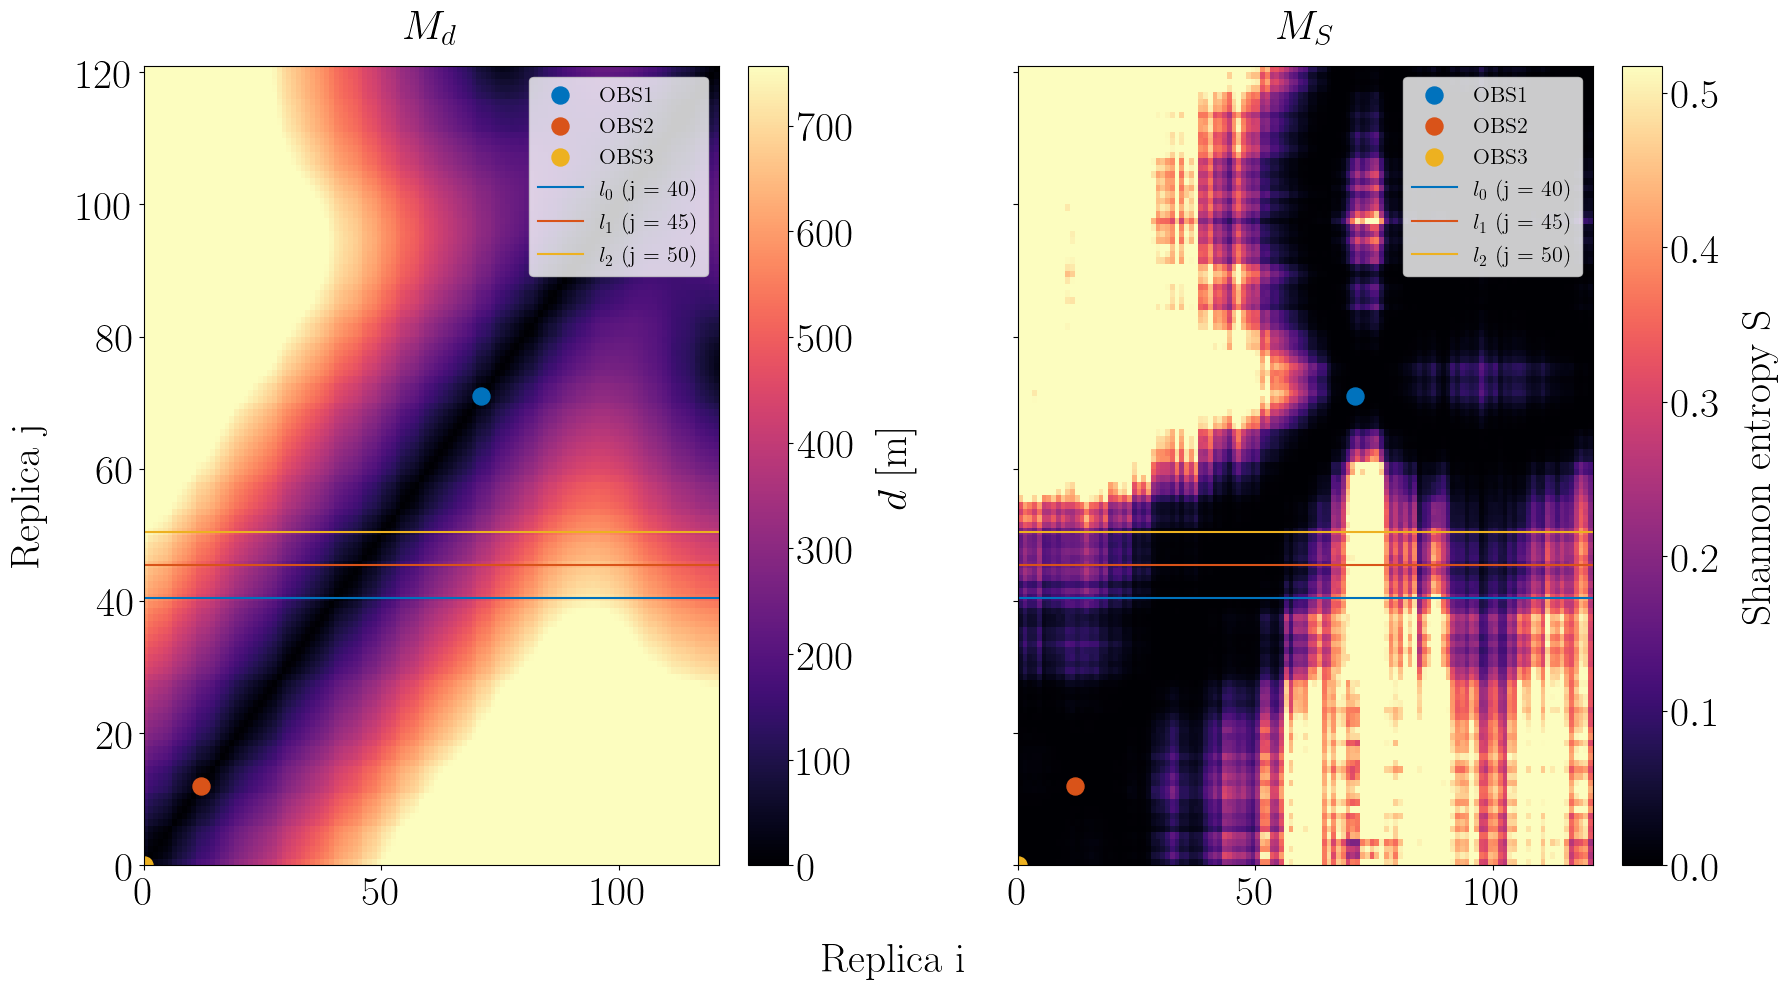

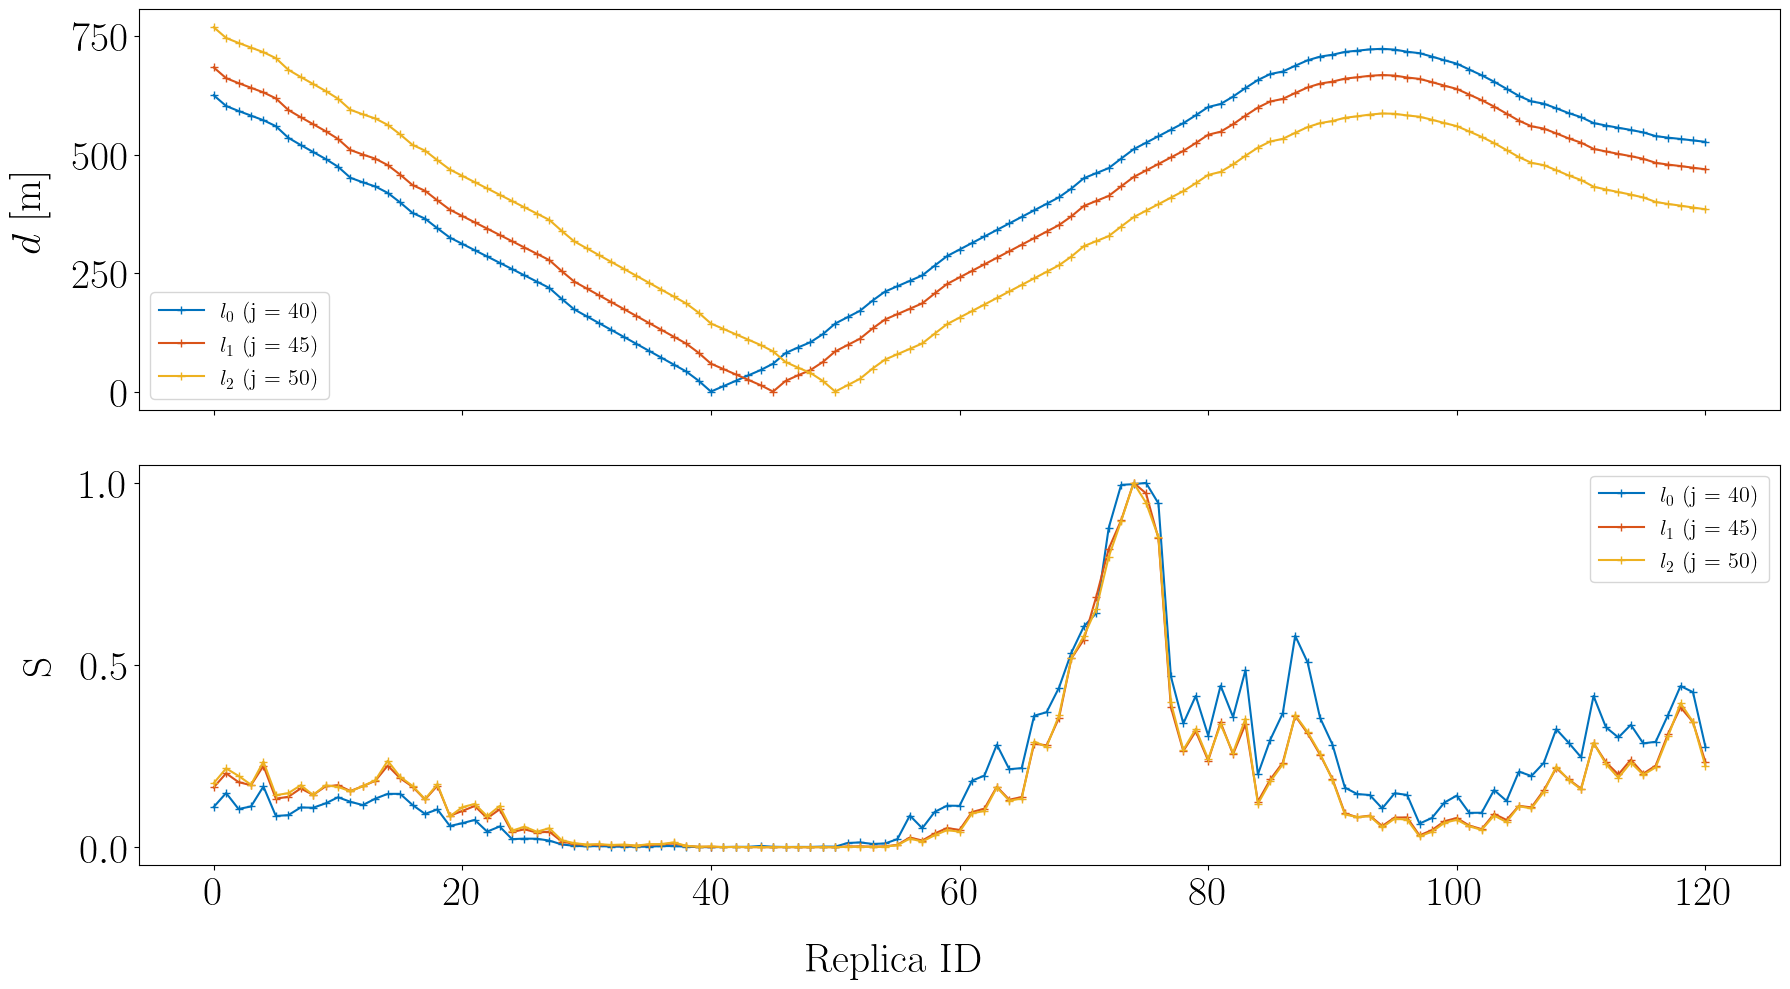

In [38]:
rcv_combinaison_strategy = "sum"

plot_distance_matrix_comparison(
    spatial_dist_mat=spatial_dist_mat,
    dist_mat=dist_mat_prod[distance],
    fig_folder=fig_folder,
    dist_type=distance,
    rcv_combinaison_strategy=rcv_combinaison_strategy,
    cpa_idx=obs_cpa_idx,
)
selected_lines = [40, 45, 50]
plot_distance_matrix_comparison_line_selected(
    spatial_dist_mat=spatial_dist_mat,
    dist_mat=dist_mat_prod[distance],
    fig_folder=fig_folder,
    dist_type=distance,
    rcv_combinaison_strategy=rcv_combinaison_strategy,
    cpa_idx=obs_cpa_idx,
    selected_lines=selected_lines,
)
plot_distance_selected_lines(
    spatial_dist_mat=spatial_dist_mat,
    dist_mat=dist_mat_prod[distance],
    fig_folder=fig_folder,
    dist_type=distance,
    rcv_combinaison_strategy=rcv_combinaison_strategy,
    selected_lines=selected_lines,
)

## Distribution jointe des deux capteurs 

### Cas de deux distributions indépendantes 

In [ ]:
fmin, fmax = 200, 900
use_kde = True
n_bins = 50
# Step 1: compute distributions for each receiver
idx_rcv_ = [idx for idx in ds.h_index.values if idx != ds.reference_receiver_id]        # All except reference receiver

# Sel frequency band of interest
ds_ = ds.sel(f_rtf=slice(fmin, fmax))

log_mod_distribution_dict = {}
for id_rcv in idx_rcv_:
    rtf_amp_rcv = ds_.rtf_amp.sel(h_index=id_rcv)

    # Compute distribution along traj
    log_mod_hist_arr, bin_centers, log_mod_kde_arr = get_distribution_arr(
        rtf_module=rtf_amp_rcv, n_bins=n_bins, kde=use_kde
    )
    # Store distribution for current receiver
    if use_kde:
        log_mod_distribution_dict[id_rcv] = log_mod_kde_arr
    else:
        log_mod_distribution_dict[id_rcv] = log_mod_hist_arr

In [ ]:
log_mod_distribution_dict[id_rcv].shape

#### Allure pour une réplique i donnée 

In [ ]:
i_rep = 40

mu_0 = log_mod_distribution_dict[idx_rcv_[0]]     # Distribution of first receiver 
mu_1 = log_mod_distribution_dict[idx_rcv_[1]]     # Distribution of second receiver

mu_i_0 = mu_0[i_rep, :]
mu_i_1 = mu_1[i_rep, :]

# Plot independent distributions
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
ax1, ax2 = axs
ax1.plot(bin_centers, mu_i_0, label=f"OBS {idx_rcv_[0]}")
ax2.plot(bin_centers, mu_i_1, label=f"OBS {idx_rcv_[1]}")

ax1.set_title(f"Distribution for OBS {idx_rcv_[0]}")
ax2.set_title(f"Distribution for OBS {idx_rcv_[1]}")
ax1.set_xlabel(r"$\lvert \Pi(f, r) \rvert$")
ax2.set_xlabel(r"$\lvert \Pi(f, r) \rvert$")
ax1.set_ylabel(r"$\mu$")
ax2.set_ylabel(r"$\mu$")

In [ ]:
# Build the 2D joint distribution assuming independence (i.e. product of the 1D distributions)
mu_i_0_1 = np.outer(mu_i_0, mu_i_1)
# Plot joint distribution
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.pcolormesh(bin_centers, bin_centers, mu_i_0_1, shading="auto", cmap="jet")
plt.colorbar(im, ax=ax, label=r"$\mu$ (joint distribution)")
ax.set_title(f"Joint distribution for OBS {idx_rcv_[0]} and OBS {idx_rcv_[1]} (assuming independence)")
ax.set_xlabel(fr"$\lvert \Pi(f, r) \rvert$ OBS {idx_rcv_[0]}")
ax.set_ylabel(fr"$\lvert \Pi(f, r) \rvert$ OBS {idx_rcv_[1]}")

In [ ]:
# Build all joint distributions
joint_distribution_mat = np.zeros(
    (len(ds.replica_id), len(bin_centers), len(bin_centers))
)
for i_rep in range(len(ds.replica_id)):
    mu_i_0 = mu_0[i_rep, :]
    mu_i_1 = mu_1[i_rep, :]

    mu_i_0_1 = np.outer(mu_i_0, mu_i_1)
    joint_distribution_mat[i_rep, :, :] = mu_i_0_1

In [ ]:
# Plot joint distribution for successives replicas
new_fig_every = 20
n_reps_plot = mu_0.shape[0]

mu_0_1 = []
for i_rep in range(n_reps_plot):

    if i_rep % new_fig_every == 0:
        fig, axs = plt.subplots(
            nrows=4, ncols=5, figsize=(20, 8), sharex=True, sharey=True
        )
        axs = axs.flatten()

        i_ax = 0

    # mu_i_0 = mu_0[i_rep, :]
    # mu_i_1 = mu_1[i_rep, :]

    # mu_i_0_1 = np.outer(mu_i_0, mu_i_1)
    # mu_0_1.append(mu_i_0_1)

    mu_i_0_1 = joint_distribution_mat[i_rep, ...]

    ax = axs[i_ax]
    im = ax.pcolormesh(bin_centers, bin_centers, mu_i_0_1, shading="auto", cmap="jet")
    ax.set_title(f"Replica {i_rep}")

    i_ax += 1

# mu_0_1 = np.array(mu_0_1)

# ax.set_xlabel(fr"$\lvert \Pi(f, r) \rvert$ OBS {idx_rcv_[0]}")
# ax.set_ylabel(fr"$\lvert \Pi(f, r) \rvert$ OBS {idx_rcv_[1]}")

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import numpy as np

# ------------------------------------------------------------------
# Precompute max indices (efficient)
# ------------------------------------------------------------------

idx_max = np.array(
    [
        np.unravel_index(np.argmax(mu_i, axis=None), mu_i.shape)
        for mu_i in joint_distribution_mat
    ]
)

# Convert to coordinates
x_max = bin_centers[idx_max[:, 1]]
y_max = bin_centers[idx_max[:, 0]]

n_reps = joint_distribution_mat.shape[0]

# ------------------------------------------------------------------
# Figure
# ------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.pcolormesh(
    bin_centers,
    bin_centers,
    joint_distribution_mat[0],
    shading="auto",
    cmap="jet",
    vmin=joint_distribution_mat.min(),
    vmax=joint_distribution_mat.max(),
)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Joint probability")

ax.set_xlabel(r"$|\Pi(f, r)|$ OBS 1")
ax.set_ylabel(r"$|\Pi(f, r)|$ OBS 2")

title = ax.set_title("Replica 0")

# ------------------------------------------------------------------
# Trajectory artists
# ------------------------------------------------------------------

# Line (trajectory)
(line_max,) = ax.plot([], [], "-", color="white", lw=2, label="Max trajectory")

# Current point
(point_max,) = ax.plot([], [], "o", color="red", zorder=5)

ax.legend()

# ------------------------------------------------------------------
# INIT
# ------------------------------------------------------------------


def init():
    im.set_array(joint_distribution_mat[0].ravel())

    line_max.set_data([], [])
    point_max.set_data([], [])

    title.set_text("Replica 0")

    return im, line_max, point_max, title


# ------------------------------------------------------------------
# UPDATE
# ------------------------------------------------------------------


def update(frame):

    # --- update heatmap ---
    data = joint_distribution_mat[frame]
    im.set_array(data.ravel())

    # --- update trajectory ---
    line_max.set_data(x_max[: frame + 1], y_max[: frame + 1])

    # --- current point ---
    point_max.set_data([x_max[frame]], [y_max[frame]])

    # --- title ---
    title.set_text(f"Replica {frame}")

    return im, line_max, point_max, title


# ------------------------------------------------------------------
# Animation
# ------------------------------------------------------------------

ani = FuncAnimation(
    fig,
    update,
    frames=n_reps,
    init_func=init,
    interval=200,
    blit=False,
)

dpi = 100
fps=5
ani.save(
    os.path.join("test.mp4"),
    writer="ffmpeg",
    fps=fps,
    dpi=dpi,
)

In [ ]:
# mean_mu_0_1 = mu_0_1.mean(axis=(1, 2))
# mean_mu_0_1.shape

# arg_max_mu_0_1 = np.argmax(mu_0_1[0, ...], keepdims=True)
# arg_max_mu_0_1

idx_max_mu_0_1 = np.array(
    [
        np.unravel_index(np.argmax(mu_i_0_1, axis=None), mu_i_0_1.shape)
        for mu_i_0_1 in joint_distribution_mat
    ]
)

In [ ]:
idx_max_mu_0_1.shape

In [ ]:
# Plot trajectory of joint distribution in the 2D space (for each replica, plot the point corresponding to the mean of the joint distribution)
fig, ax = plt.subplots(figsize=(8, 6))
cum_mu_0_1 = np.sum(joint_distribution_mat, axis=0)
im = ax.pcolormesh(bin_centers, bin_centers, cum_mu_0_1, shading="auto", cmap="magma")
plt.plot(
    bin_centers[idx_max_mu_0_1[:, 1]],
    bin_centers[idx_max_mu_0_1[:, 0]],
    marker="+",
    color="k",
    # c=np.arange(idx_max_mu_0_1.shape[0]),
)
sc = plt.scatter(bin_centers[idx_max_mu_0_1[:, 1]], bin_centers[idx_max_mu_0_1[:, 0]], marker="+", c=np.arange(idx_max_mu_0_1.shape[0]), s=30, zorder=5, cmap="jet")
plt.colorbar(sc)

In [ ]:
# Compute Wasserstein distance between joint distributions
idx_rep_ref = 70
wasserstein_distances = np.zeros(len(ds.replica_id))
for i_rep in range(len(ds.replica_id)):
    mu_i_0_1 = joint_distribution_mat[i_rep, :, :]
    mu_ref = joint_distribution_mat[idx_rep_ref, :, :]
    wd = wasserstein_distance_nd(mu_ref, mu_i_0_1)
    wasserstein_distances[i_rep] = wd

# Normalize distances
wasserstein_distances = (wasserstein_distances - wasserstein_distances.min()) / (
    wasserstein_distances.max() - wasserstein_distances.min()
)

In [ ]:
# Plot wasserstein distances
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(ds.replica_id.values, wasserstein_distances, marker="+")
ax.set_xlabel("Replica ID")
ax.set_ylabel("Wasserstein 2D")
plt.savefig("test")


In [ ]:
# Processing by sub band
use_kde = False
n_bins = 100
idx_rcv_ = [
    idx for idx in ds.h_index.values if idx != ds.reference_receiver_id
]  # All except reference receiver

idx_rep_ref = 120

f_bw = 25
fmin = ds.f_rtf.values.min()
fmax = fmin + f_bw

wdist = []
fmin_wd = []
fmax_wd = []

while fmax < ds.f_rtf.max():

    # Sel frequency band of interest
    ds_ = ds.sel(f_rtf=slice(fmin, fmax))

    # Step 1: compute distributions for each receiver
    log_mod_distribution_dict = {}
    for id_rcv in idx_rcv_:
        rtf_amp_rcv = ds_.rtf_amp.sel(h_index=id_rcv)

        # Compute distribution along traj
        log_mod_hist_arr, bin_centers, log_mod_kde_arr = get_distribution_arr(
            rtf_module=rtf_amp_rcv, n_bins=n_bins, kde=use_kde
        )
        # Store distribution for current receiver
        if use_kde:
            log_mod_distribution_dict[id_rcv] = log_mod_kde_arr
        else:
            log_mod_distribution_dict[id_rcv] = log_mod_hist_arr

    # Build all joint distributions
    mu_0 = log_mod_distribution_dict[idx_rcv_[0]]  # Distribution of first receiver
    mu_1 = log_mod_distribution_dict[idx_rcv_[1]]  # Distribution of second receiver

    joint_distribution_mat = np.zeros(
        (len(ds.replica_id), len(bin_centers), len(bin_centers))
    )
    for i_rep in range(len(ds.replica_id)):
        mu_i_0 = mu_0[i_rep, :]
        mu_i_1 = mu_1[i_rep, :]

        mu_i_0_1 = np.outer(mu_i_0, mu_i_1)
        joint_distribution_mat[i_rep, :, :] = mu_i_0_1

    # Compute Wasserstein distance between joint distributions
    wasserstein_distances = np.zeros(len(ds.replica_id))
    for i_rep in range(len(ds.replica_id)):
        mu_i_0_1 = joint_distribution_mat[i_rep, :, :]
        mu_ref = joint_distribution_mat[idx_rep_ref, :, :]
        wd = wasserstein_distance_nd(mu_ref, mu_i_0_1)
        wasserstein_distances[i_rep] = wd

    # Normalize distances
    wasserstein_distances = (wasserstein_distances - wasserstein_distances.min()) / (
        wasserstein_distances.max() - wasserstein_distances.min()
    )

    wdist.append(wasserstein_distances)
    # print(fmin, fmax)
    fmin_wd.append(fmin)
    fmax_wd.append(fmax)
    # print(fmin_wd, fmax_wd)

    fmin += f_bw
    fmax += f_bw 

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
wdist_sum = np.zeros_like(wdist[0])
wdist_prod = np.ones_like(wdist[0])

for i_fwd in range(len(wdist)):
    # Plot wasserstein distances
    ax.plot(
        ds.replica_id.values,
        wdist[i_fwd],
        color=color(i_fwd),
        # label=f"{fmin_wd[i_fwd]:.1f} Hz - {fmax_wd[i_fwd]:.1f} Hz",
    )
    ax.set_xlabel("Replica ID")
    ax.set_ylabel("Wasserstein 2D")

    wdist_sum += wdist[i_fwd]
    wdist_prod *= 1/(wdist[i_fwd] +1e-12)

# plt.legend()

# plt.savefig("test")

# wdist_prod = (wdist_prod - wdist_prod.min()) / (wdist_prod.max() - wdist_prod.min())
# wdist_sum = (wdist_sum - wdist_sum.min()) / (wdist_sum.max() - wdist_sum.min())
wdist_prod = 1 / wdist_prod
wdist_sum = 1 / len(wdist) * wdist_sum

In [ ]:
fig, ax = plt.subplots(ncols=2, figsize=(8, 6))
# Plot wasserstein distances
ax[0].plot(
    ds.replica_id.values,
    wdist_sum,
    color=color(0),
    label=f"sum",
    marker="+"
)
ax[0].set_yscale("log")
ax[1].plot(ds.replica_id.values, wdist_prod, color=color(1), label=f"prod", marker="+")
ax[1].set_xlabel("Replica ID")
ax[1].set_ylabel("Wasserstein 2D")
ax[1].set_yscale("log")
ax[1].legend()

# plt.ylim([0, 0.001])

In [ ]:
import time 

In [ ]:
def get_bootstrap_dist_matrix_joint_distribution(ds_, fmin=400, fmax=800, n_bins=100, use_kde=False):

    # Step 1: compute distributions for each receiver
    idx_rcv_ = [idx for idx in ds_.h_index.values if idx != ds_.reference_receiver_id]        # All except reference receiver

    # Sel frequency band of interest
    ds_ = ds_.sel(f_rtf=slice(fmin, fmax))

    log_mod_distribution_dict = {}
    for id_rcv in idx_rcv_:
        rtf_amp_rcv = ds_.rtf_amp.sel(h_index=id_rcv)

        # Compute distribution along traj
        log_mod_hist_arr, bin_centers, log_mod_kde_arr = get_distribution_arr(
            rtf_module=rtf_amp_rcv, n_bins=n_bins, kde=use_kde
        )
        # Store distribution for current receiver
        if use_kde:
            log_mod_distribution_dict[id_rcv] = log_mod_kde_arr
        else:
            log_mod_distribution_dict[id_rcv] = log_mod_hist_arr

    # Step 2: Build all joint distribution
    mu_0 = log_mod_distribution_dict[idx_rcv_[0]]     # Distribution of first receiver 
    mu_1 = log_mod_distribution_dict[idx_rcv_[1]]     # Distribution of second receiver

    joint_distribution_mat = np.zeros(
        (len(ds_.replica_id), len(bin_centers), len(bin_centers))
    )
    for i_rep in range(len(ds_.replica_id)):
        mu_i_0 = mu_0[i_rep, :]
        mu_i_1 = mu_1[i_rep, :]

        mu_i_0_1 = np.outer(mu_i_0, mu_i_1)
        joint_distribution_mat[i_rep, :, :] = mu_i_0_1

    # Step 3: Compute Wasserstein distance between joint distributions
    dist_mat = []
    for i, id_ref in enumerate(ds_.replica_id.values): 
        mu_ref = joint_distribution_mat[id_ref, :, :]
        wasserstein_distances = np.zeros(len(ds_.replica_id))
        # t0 = time.time()
        for i_rep in range(len(ds_.replica_id)):
            mu_i_0_1 = joint_distribution_mat[i_rep, :, :]
            wd = wasserstein_distance_nd(mu_ref, mu_i_0_1)
            wasserstein_distances[i_rep] = wd
        dist_mat.append(wasserstein_distances)

        # print(time.time() - t0)

    dist_mat = np.array(dist_mat)

    # Step 4 : normalize distance matrix to fall into [0, 1] for comparison purpose
    dist_mat = (dist_mat - dist_mat.min()) / (dist_mat.max() - dist_mat.min())

    return dist_mat

In [ ]:
dist_type = "wasserstein_2d"
rcv_combinaison_strategy="joint_distribution"

ds_ = ds
M_data_joint = get_bootstrap_dist_matrix_joint_distribution(
    ds_, fmin=400, fmax=800, n_bins=100, use_kde=False
)

In [ ]:
plot_distance_matrix_comparison(
    spatial_dist_mat=spatial_dist_mat,
    dist_mat=M_data_joint,
    fig_folder=fig_folder,
    dist_type=dist_type,
    rcv_combinaison_strategy=rcv_combinaison_strategy,
    cpa_idx=obs_cpa_idx,
)
selected_lines = [65, 75, 85]
plot_distance_matrix_comparison_line_selected(
    spatial_dist_mat=spatial_dist_mat,
    dist_mat=M_data_joint,
    fig_folder=fig_folder,
    dist_type=dist_type,
    rcv_combinaison_strategy=rcv_combinaison_strategy,
    cpa_idx=obs_cpa_idx,
    selected_lines=selected_lines,
)
plot_distance_selected_lines(
    spatial_dist_mat=spatial_dist_mat,
    dist_mat=M_data_joint,
    fig_folder=fig_folder,
    dist_type=dist_type,
    rcv_combinaison_strategy=rcv_combinaison_strategy,
    selected_lines=selected_lines,
)